____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

In [3]:
def compute_mean_square(ds):
    var = ['acc', 'cor', 'ggd', 'wd','sum']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']
    dss = (ds[[v+'n' for v in var] + [v+'e' for v in var]]**2).mean(dim='row_number').rename({var[i]+'n' : VAR[i]+'n' for i in range(5)}).rename({var[i]+'e' : VAR[i]+'e' for i in range(5)})
    dss['sigmae'] = dss.ACCe + dss.CORe + dss.GGDe + dss.WDe
    dss['sigman'] = dss.ACCn + dss.CORn + dss.GGDn + dss.WDn
    dss['nb_coloc'] = len(ds.row_number)
    #Balanced and error
    for direction in ['e', 'n']:
        for v in ['acc', 'cor', 'ggd', 'wd'] : 
                dss['B'+direction+'_'+v] = -((ds[v+direction]*ds['exc'+direction+'_'+v])).mean(dim='row_number')
                dss['E'+direction+'_'+v] = ((ds[v+direction]*ds['sum'+direction])).mean(dim='row_number')
    #pairs contributions
    for v in [v for v in ds if 'prod' in v]:
        dss[v.replace('prod', 'X')]=-2*ds[v].mean(dim='row_number')
    return dss

__________________
## Sensitivity to SWOT-250m filtering

(array([  208.55057351,   208.55057351,   625.65172054,   625.65172054,
         1251.30344108,  3753.91032325,  6465.06777894,  9384.77580813,
        16892.59645464, 19186.6527633 , 28779.97914494, 31491.13660063,
        24191.86652763, 18978.10218978, 15849.84358707,  9801.87695516,
         4796.66319082,  4379.5620438 ,  1459.8540146 ,   208.55057351,
          625.65172054,   208.55057351,   625.65172054]),
 array([-6.00000000e-05, -5.50000000e-05, -5.00000000e-05, -4.50000000e-05,
        -4.00000000e-05, -3.50000000e-05, -3.00000000e-05, -2.50000000e-05,
        -2.00000000e-05, -1.50000000e-05, -1.00000000e-05, -5.00000000e-06,
        -6.77626358e-21,  5.00000000e-06,  1.00000000e-05,  1.50000000e-05,
         2.00000000e-05,  2.50000000e-05,  3.00000000e-05,  3.50000000e-05,
         4.00000000e-05,  4.50000000e-05,  5.00000000e-05,  5.50000000e-05]),
 <BarContainer object of 23 artists>)

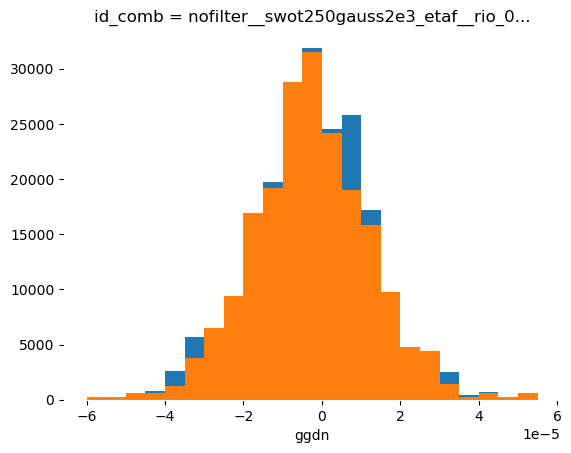

In [53]:
s = DSS.sel(id_comb = 'nofilter__swot250gauss2e3_etaf__rio_0era5')
d = DSD.sel(id_comb = 'nofilter__swot250gauss2e3_etaf__rio_0era5')


s.ggdn.plot.hist(bins = np.arange(-6e-5,6e-5, 5e-6), density=True)
d.ggdn.plot.hist(bins = np.arange(-6e-5,6e-5, 5e-6), density=True)

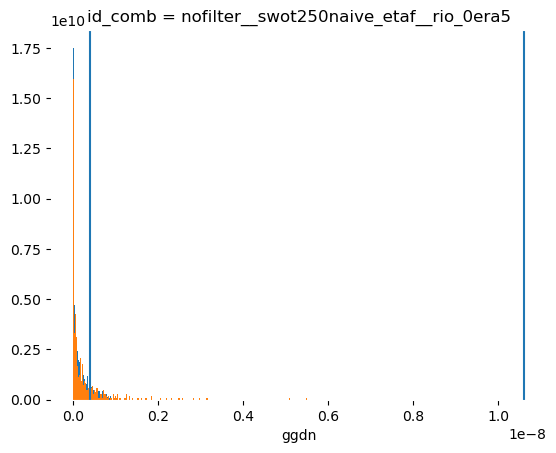

In [66]:
s = DSS.sel(id_comb = 'nofilter__swot250naive_etaf__rio_0era5')
d = DSD.sel(id_comb = 'nofilter__swot250naive_etaf__rio_0era5')


(s**2).ggdn.plot.hist(bins = np.arange(0, 1e-9, 1e-11), density=True)
(d**2).ggdn.plot.hist(bins = np.arange(0, 1e-8, 1e-11),density=True)

plt.axvline((s**2).ggdn.mean('row_number'))
plt.axvline((d**2).ggdn.mean('row_number'))

In [71]:
d['ggdn2']=d.ggdn**2
s['ggdn2']=s.ggdn**2

dpb = d.where(d.ggdn2>1e-8, drop=True)
dnpb = d.where(d.ggdn2<1e-8, drop=True)

In [73]:
dnpb.ggdn2.max(), s.ggdn2.max()

(<xarray.DataArray 'ggdn2' ()> Size: 8B
 array(6.91873051e-09)
 Coordinates:
     id_comb  <U41 164B 'nofilter__swot250naive_etaf__rio_0era5',
 <xarray.DataArray 'ggdn2' ()> Size: 8B
 array(1.72502678e-08)
 Coordinates:
     id_comb  <U41 164B 'nofilter__swot250naive_etaf__rio_0era5')

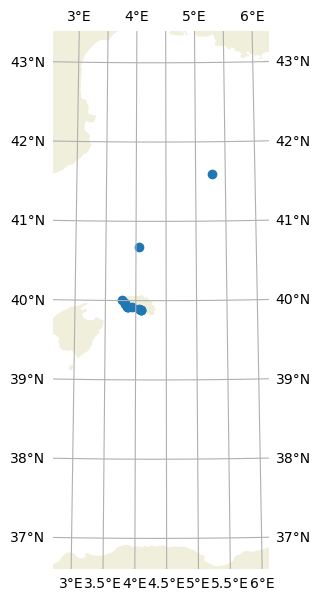

In [69]:
fig = plt.figure(figsize=(12,7), frameon=False)

ax = fig.add_subplot(111, projection=ccrs.Orthographic(d.longitude.mean().values, d.latitude.mean().values))
#a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
bbox = [2.7, 6.1, 36.6, 43.4]
a = ax.scatter(dpb.longitude, dpb.latitude, transform =crs)
ax.set_extent(bbox)
ax.add_feature(cfeature.LAND,)

gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False


In [70]:
dpb

<xarray.Dataset> Size: 5kB
Dimensions:        (row_number: 15)
Coordinates:
    datetime       (row_number) datetime64[ns] 120B 2023-04-19T21:10:00 ... 2...
    longitude      (row_number) float64 120B 5.284 4.09 4.084 ... 1.451 1.338
    latitude       (row_number) float64 120B 41.59 39.88 39.88 ... 41.15 41.09
    pass_number    (row_number) float64 120B 3.0 3.0 3.0 3.0 ... 3.0 16.0 16.0
    time_to_swot   (row_number) object 120B '0 days 00:16:04.069197888' ... '...
    cycle_number   (row_number) float64 120B 496.0 513.0 514.0 ... 529.0 563.0
    drifter_id     (row_number) object 120B '300534062470440' ... '3005340600...
    drifter_type   (row_number) object 120B 'SVP' 'SVP' 'SVP' ... 'SVP' 'SVP'
    depth          (row_number) float64 120B 15.0 15.0 15.0 ... 15.0 15.0 15.0
  * row_number     (row_number) int64 120B 45777 113720 121393 ... 316940 370249
    id_comb        <U41 164B 'nofilter__swot250naive_etaf__rio_0era5'
Data variables: (12/31)
    sume           (row_number) float64 120B -8.012e-06 0.0003408 ... 3.811e-05
    acce           (row_number) float64 120B 4.183e-06 -1.299e-05 ... -3.168e-06
    exce_acc       (row_number) float64 120B -1.22e-05 0.0003538 ... 4.127e-05
    core           (row_number) float64 120B 2.712e-06 -2.57e-06 ... -6.807e-06
    exce_cor       (row_number) float64 120B -1.072e-05 0.0003433 ... 4.491e-05
    ggde           (row_number) float64 120B -1.498e-05 0.0003561 ... 4.709e-05
    ...             ...
    prodn_acc_ggd  (row_number) float64 120B -9.873e-10 5.536e-09 ... -5.571e-10
    prodn_acc_wd   (row_number) float64 120B -1.758e-12 1.149e-11 ... 8.717e-13
    prodn_cor_ggd  (row_number) float64 120B -5.174e-09 -5.231e-09 ... 8.817e-10
    prodn_cor_wd   (row_number) float64 120B -9.213e-12 ... -1.379e-12
    prodn_ggd_wd   (row_number) float64 120B 3.503e-11 1.166e-09 ... -2.697e-11
    ggdn2          (row_number) float64 120B 1.967e-08 5.62e-07 ... 1.724e-08

In [52]:
dd2.where(d2>1e-8, drop=True)

<xarray.DataArray 'ggdn' (row_number: 10)> Size: 80B
array([9.26672278e-08, 9.79660749e-08, 3.88132416e-07, 2.10346030e-08,
       6.24200418e-08, 7.92627664e-08, 2.51089547e-07, 9.12526596e-08,
       5.50927986e-08, 1.13697594e-08])
Coordinates:
    datetime      (row_number) datetime64[ns] 80B 2023-05-06T18:10:00 ... 202...
    longitude     (row_number) float64 80B 4.093 4.084 4.083 ... 3.875 4.056
    latitude      (row_number) float64 80B 39.88 39.88 39.89 ... 39.92 40.67
    pass_number   (row_number) float64 80B 3.0 3.0 3.0 3.0 ... 3.0 3.0 3.0 3.0
    time_to_swot  (row_number) object 80B '0 days 00:04:38.739240896' ... '0 ...
    cycle_number  (row_number) float64 80B 513.0 514.0 515.0 ... 523.0 535.0
    drifter_id    (row_number) object 80B '300534062474750' ... '300534062479...
    drifter_type  (row_number) object 80B 'SVP' 'SVP' 'SVP' ... 'SVP' 'SVP'
    depth         (row_number) float64 80B 15.0 15.0 15.0 ... 15.0 15.0 15.0
  * row_number    (row_number) int64 80B 113709 121393 127608 ... 164523 198749
    id_comb       <U41 164B 'nofilter__swot250gauss2e3_etaf__rio_0era5'

In [23]:
(DSS.sel(id_comb = 'nofilter__swot250gauss2e3_etaf__rio_0era5').ggdn**2).mean('row_number') , (DSD.sel(id_comb = 'nofilter__swot250gauss2e3_etaf__rio_0era5').ggdn**2).mean('row_number')

(<xarray.DataArray 'ggdn' ()> Size: 8B
 array(2.423605e-10)
 Coordinates:
     id_comb  <U41 164B 'nofilter__swot250gauss2e3_etaf__rio_0era5',
 <xarray.DataArray 'ggdn' ()> Size: 8B
 array(1.44548689e-09)
 Coordinates:
     id_comb  <U41 164B 'nofilter__swot250gauss2e3_etaf__rio_0era5')

(array([  1.,   1.,   3.,   3.,   6.,  18.,  31.,  45.,  81.,  92., 138.,
        151., 116.,  91.,  76.,  47.,  23.,  21.,   7.,   1.,   3.,   1.,
          3.]),
 array([-6.00000000e-05, -5.50000000e-05, -5.00000000e-05, -4.50000000e-05,
        -4.00000000e-05, -3.50000000e-05, -3.00000000e-05, -2.50000000e-05,
        -2.00000000e-05, -1.50000000e-05, -1.00000000e-05, -5.00000000e-06,
        -6.77626358e-21,  5.00000000e-06,  1.00000000e-05,  1.50000000e-05,
         2.00000000e-05,  2.50000000e-05,  3.00000000e-05,  3.50000000e-05,
         4.00000000e-05,  4.50000000e-05,  5.00000000e-05,  5.50000000e-05]),
 <BarContainer object of 23 artists>)

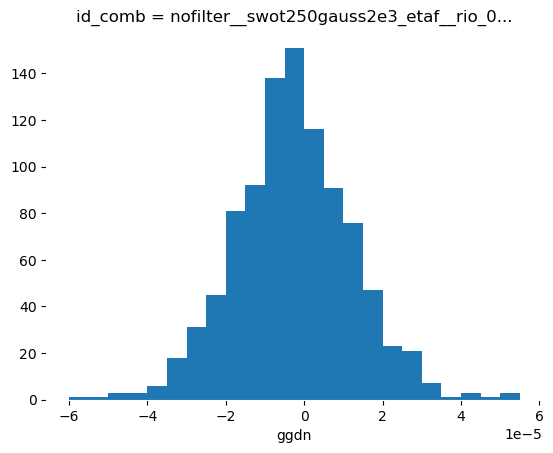

In [15]:
DSD.sel(id_comb = 'nofilter__swot250gauss2e3_etaf__rio_0era5').ggdn.plot.hist(bins = np.arange(-6e-5,6e-5, 5e-6))

nofilter__swot250naive_etaf__rio_0era5
nofilter__swot250gauss1e3_etaf__rio_0era5
nofilter__swot250gauss2e3_etaf__rio_0era5
nofilter__swot250gauss3e3_etaf__rio_0era5
nofilter__swot250gauss4e3_etaf__rio_0era5
nofilter__swot250gauss5e3_etaf__rio_0era5
27.70197048258177
28.209592250346965
114.4360660140279
115.95473050716784
13.41352490158049
13.826324476832554
61.534207499253036
62.44286149316309
10.469307603939153
10.921079217779267
19.20159519152587
19.6732364556948
8.584978764911535
9.133123061083893
11.330935187175623
11.726588326667327
7.252676343873904
7.524358215765473
8.52479016972963
9.025123786234934
5.655103351842206
5.978317199182732
7.424708701258239
7.962838674276588


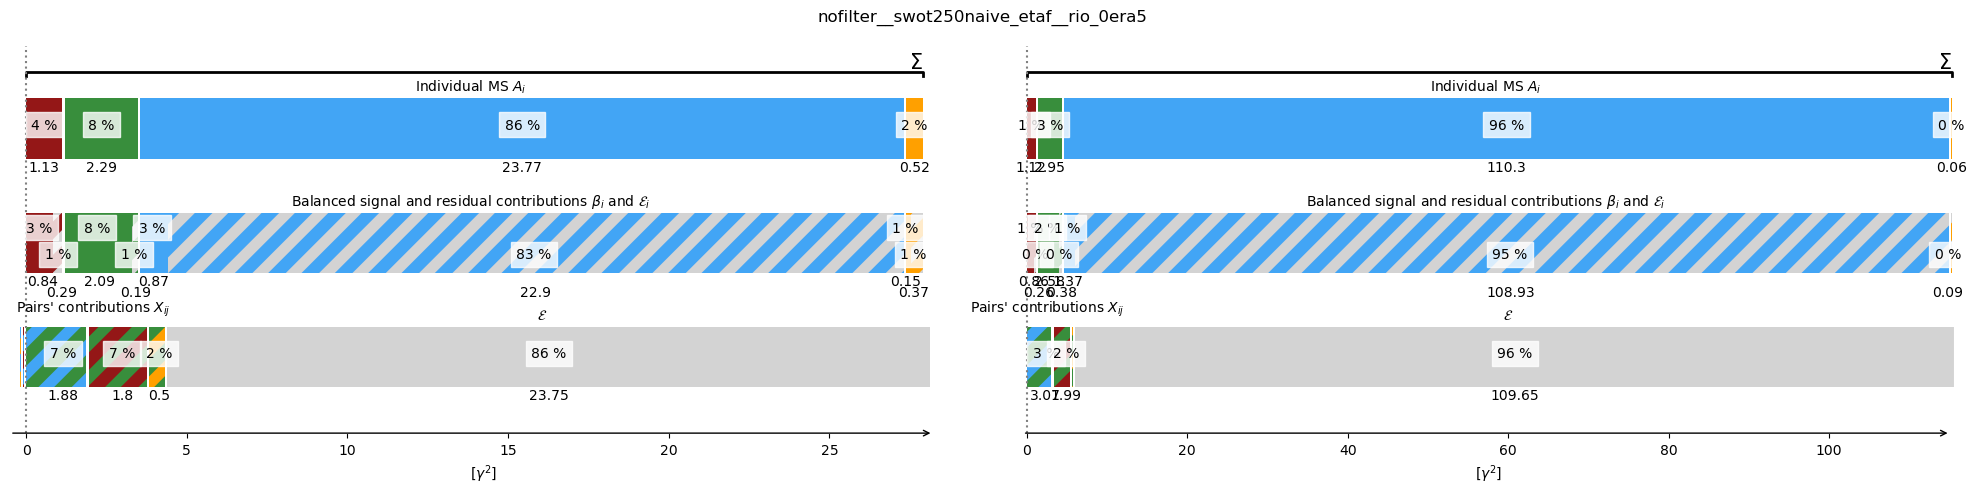

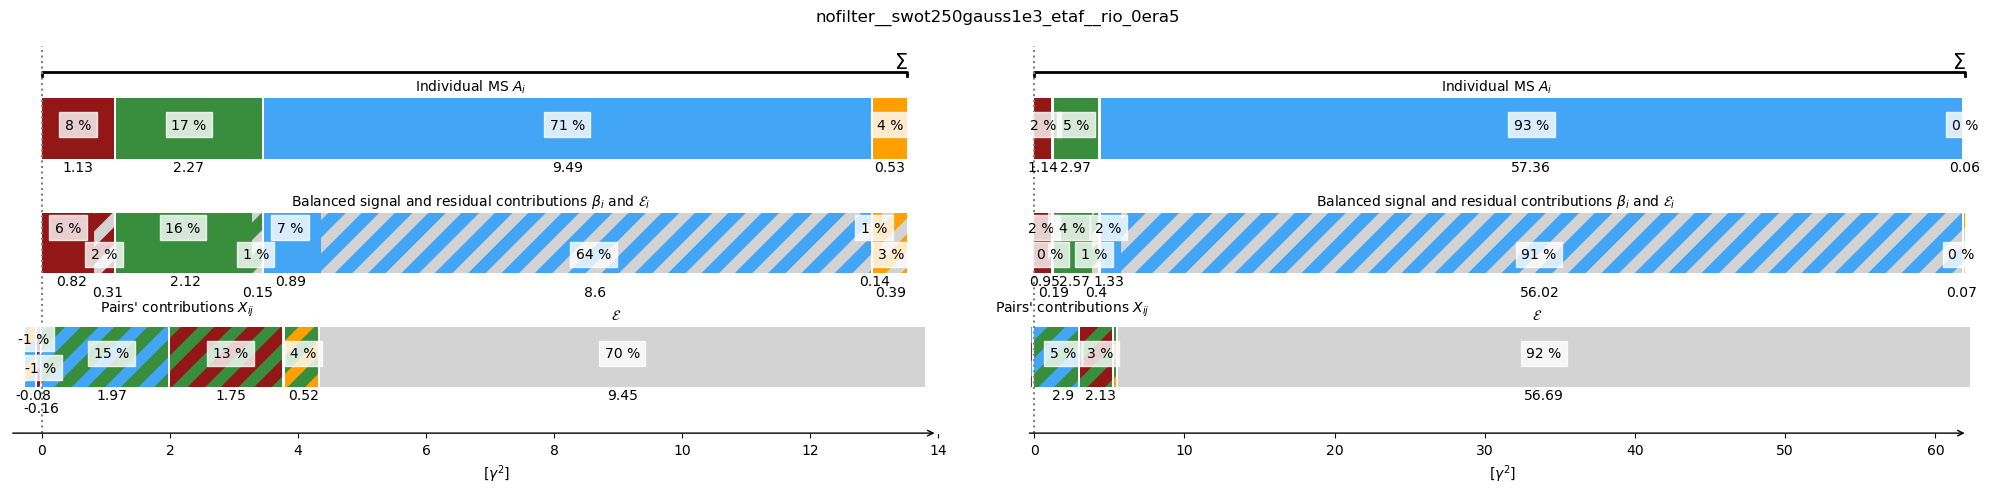

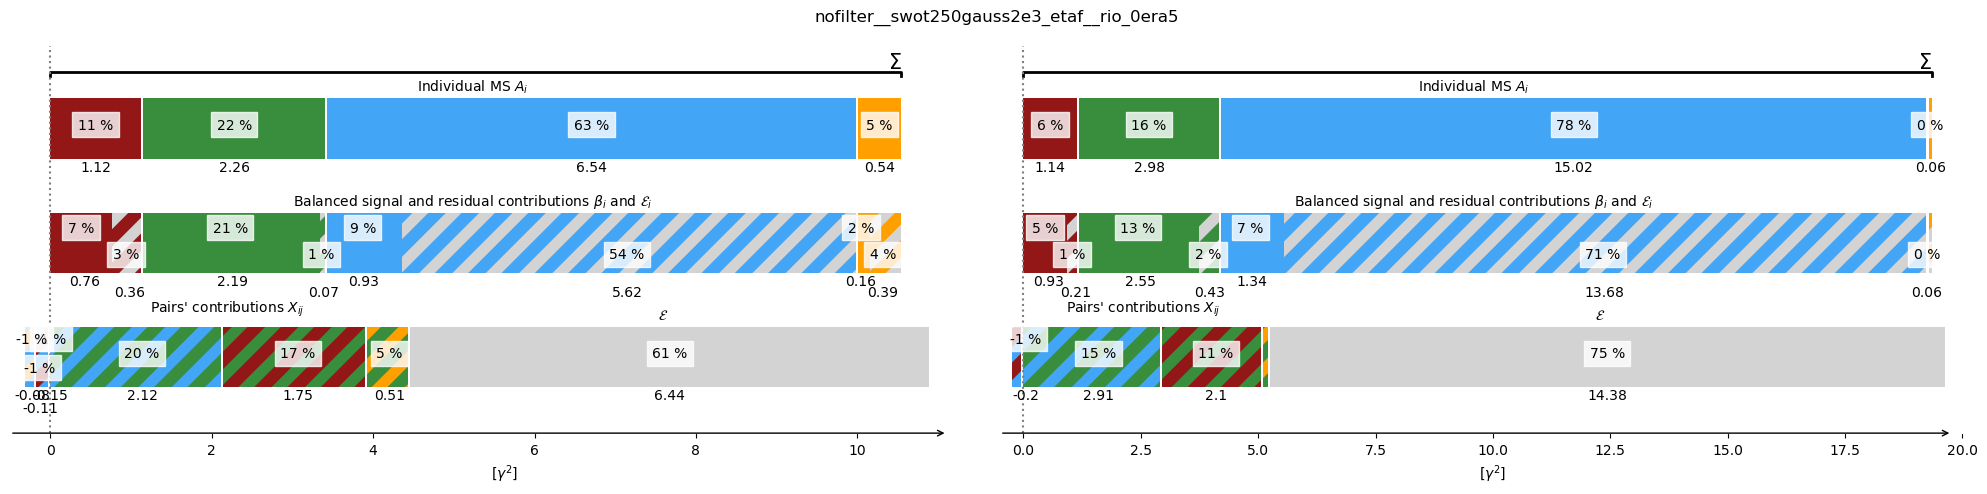

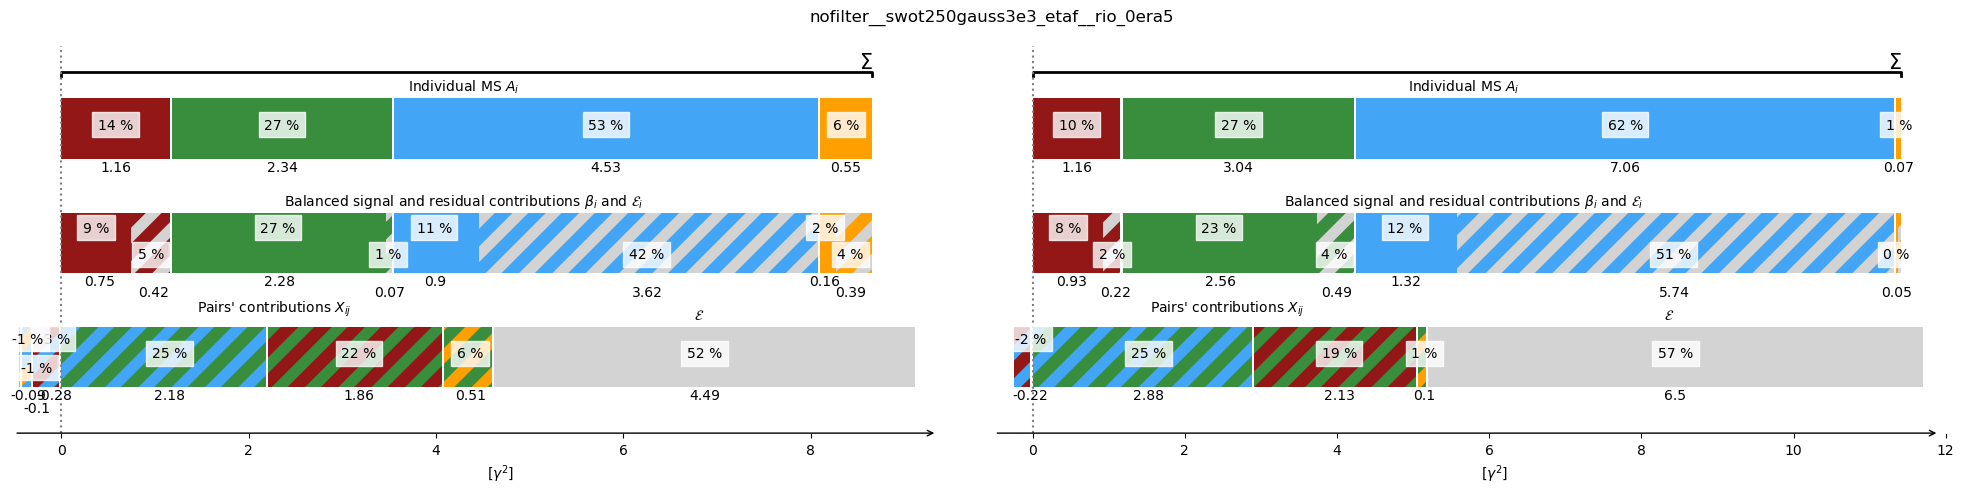

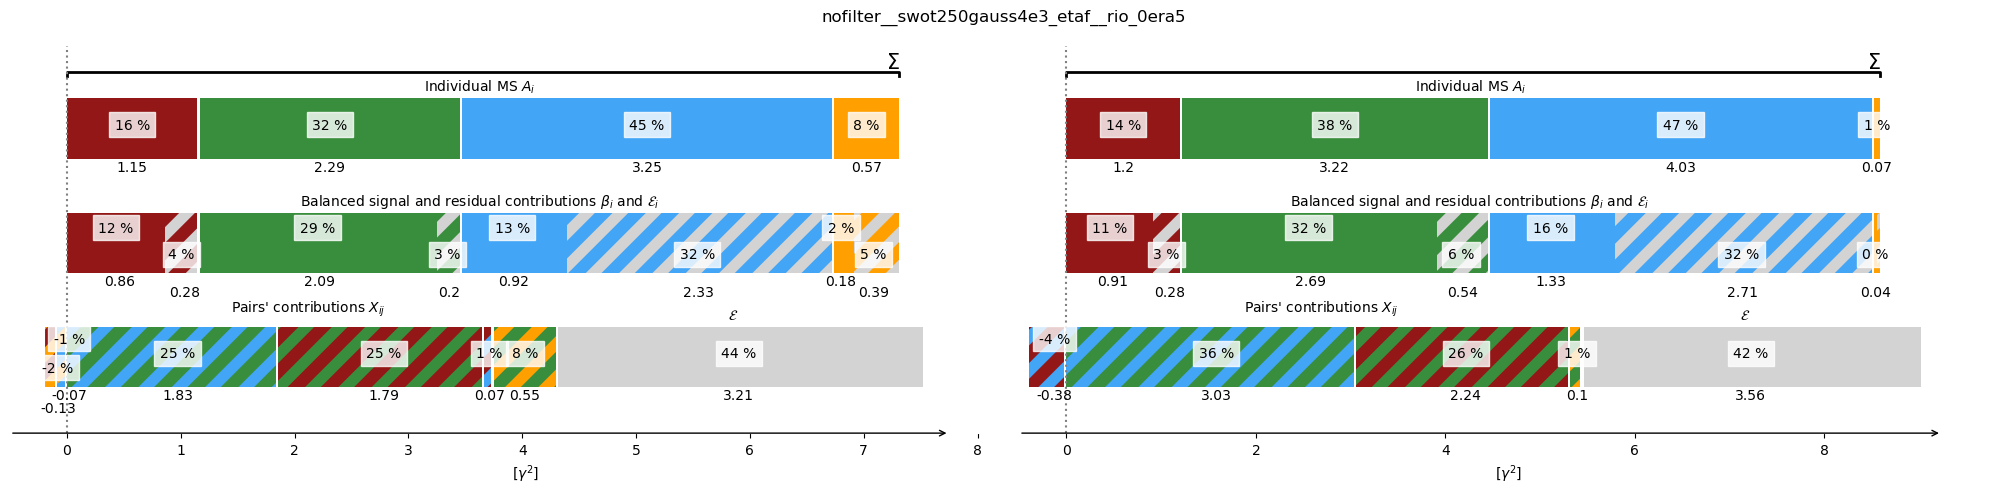

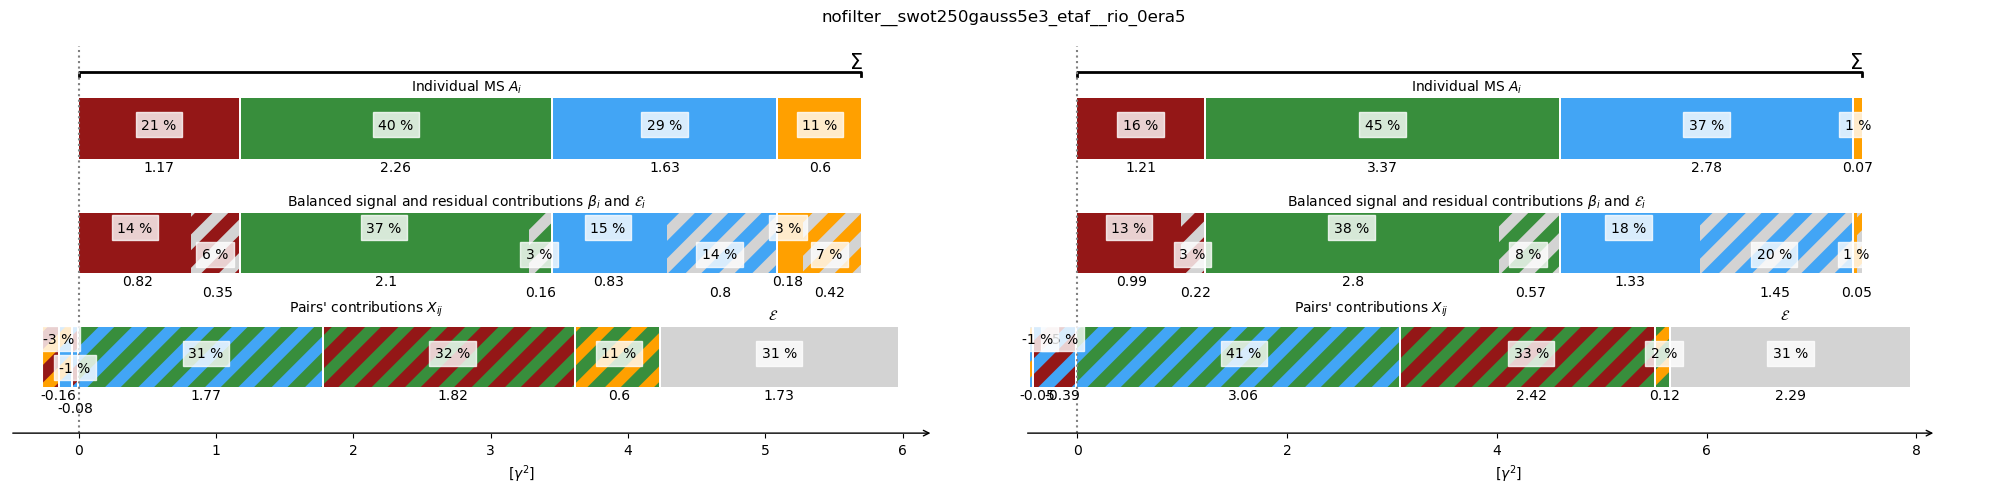

In [7]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss1e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss3e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss4e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'swot250gauss5e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0')]

DS = dataset_coloc_combs(comb_list, nearest =True)
DSS = DS.where(DS.depth==0, drop=True)
DSD = DS.where(DS.depth==15, drop=True)
ds = compute_mean_square(DSD)/U2
df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e')
    synthetic_figure(df.loc[c], axs[1], dir='n')
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

nofilter__swot250naive_etaf__rio_0era5
nofilter__swot250gauss1e3_etaf__rio_0era5
nofilter__swot250gauss2e3_etaf__rio_0era5
nofilter__swot250gauss3e3_etaf__rio_0era5
nofilter__swot250gauss4e3_etaf__rio_0era5
nofilter__swot250gauss5e3_etaf__rio_0era5
9.578986655962455
10.076061823436193
10.737874544001581
10.917288072328919
9.017750530626632
9.543576456275355
9.983659717497728
10.164456732287196
8.753248452798141
9.346656749383559
9.191661449056664
9.407543087179821
8.426665410764883
9.026184430343612
9.0134870605831
9.381942576880158
8.180080261816517
8.767346833195699
8.868973604188364
9.311674403861597
8.072185139781501
8.661838284365896
8.730016031195584
9.177827544640273


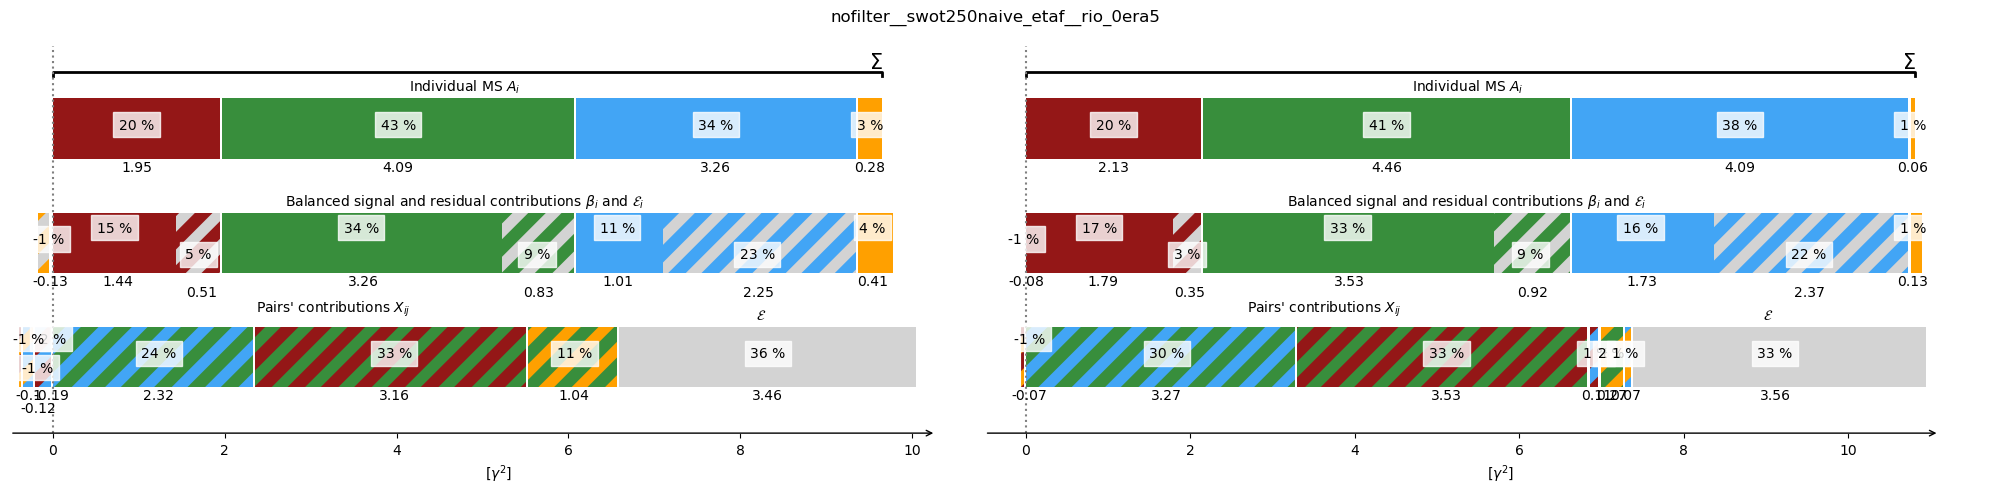

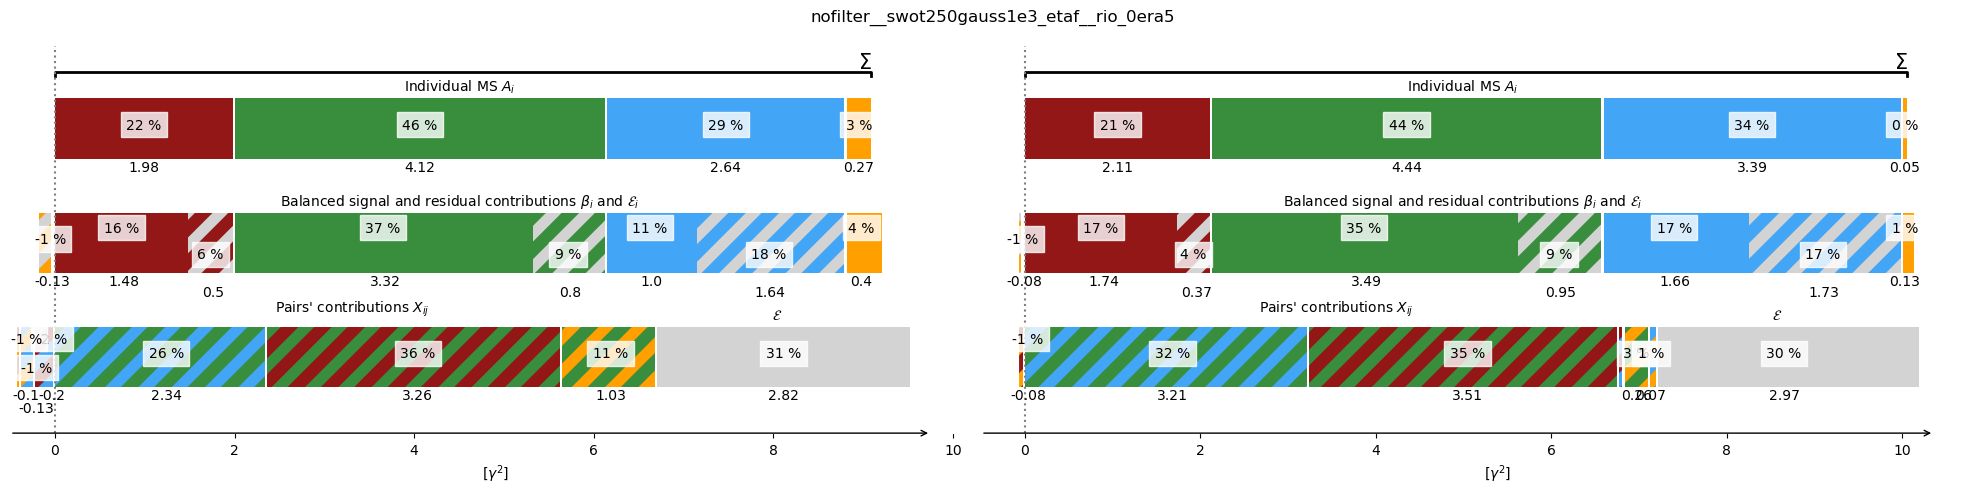

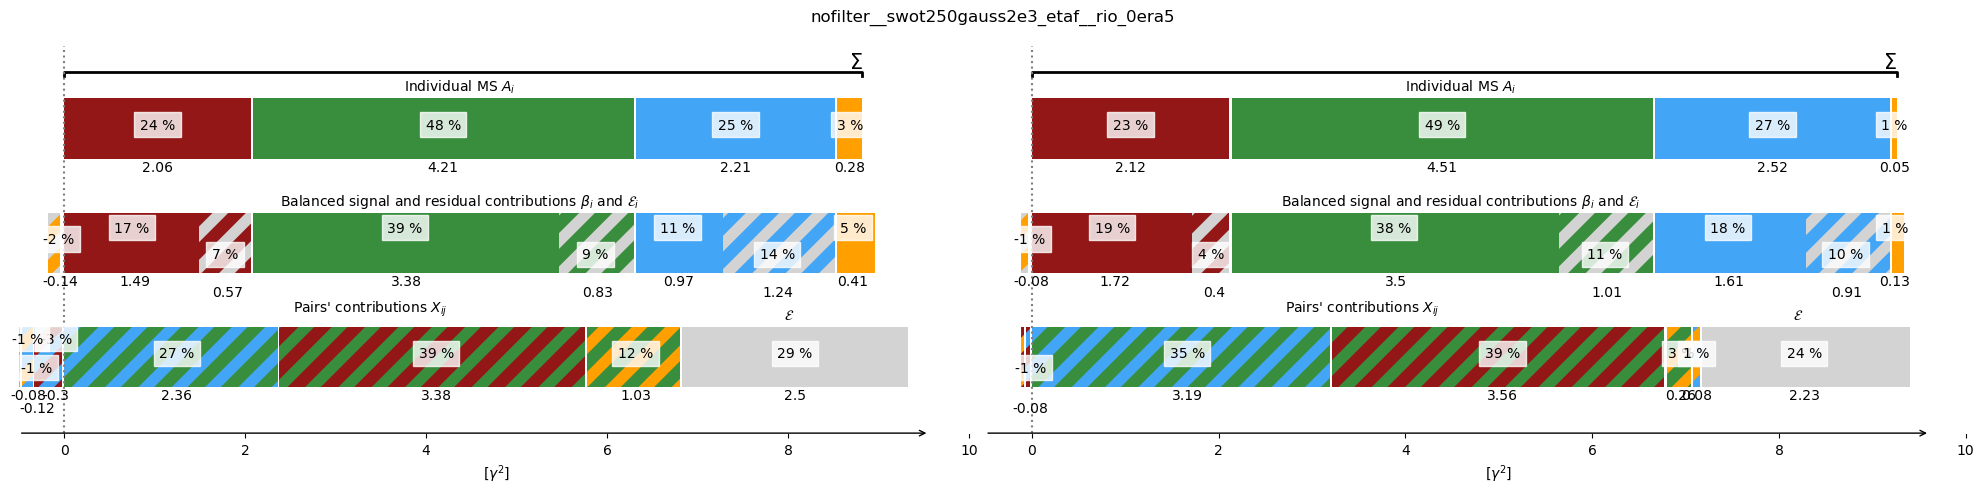

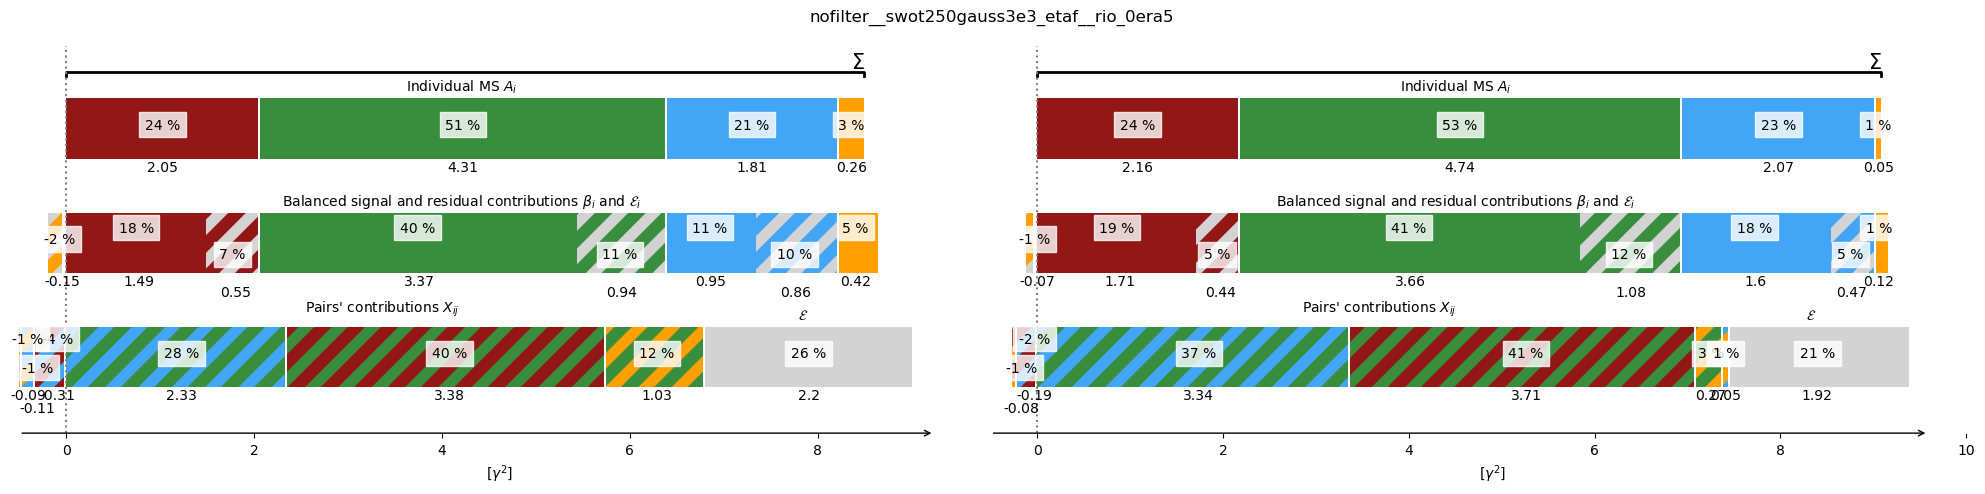

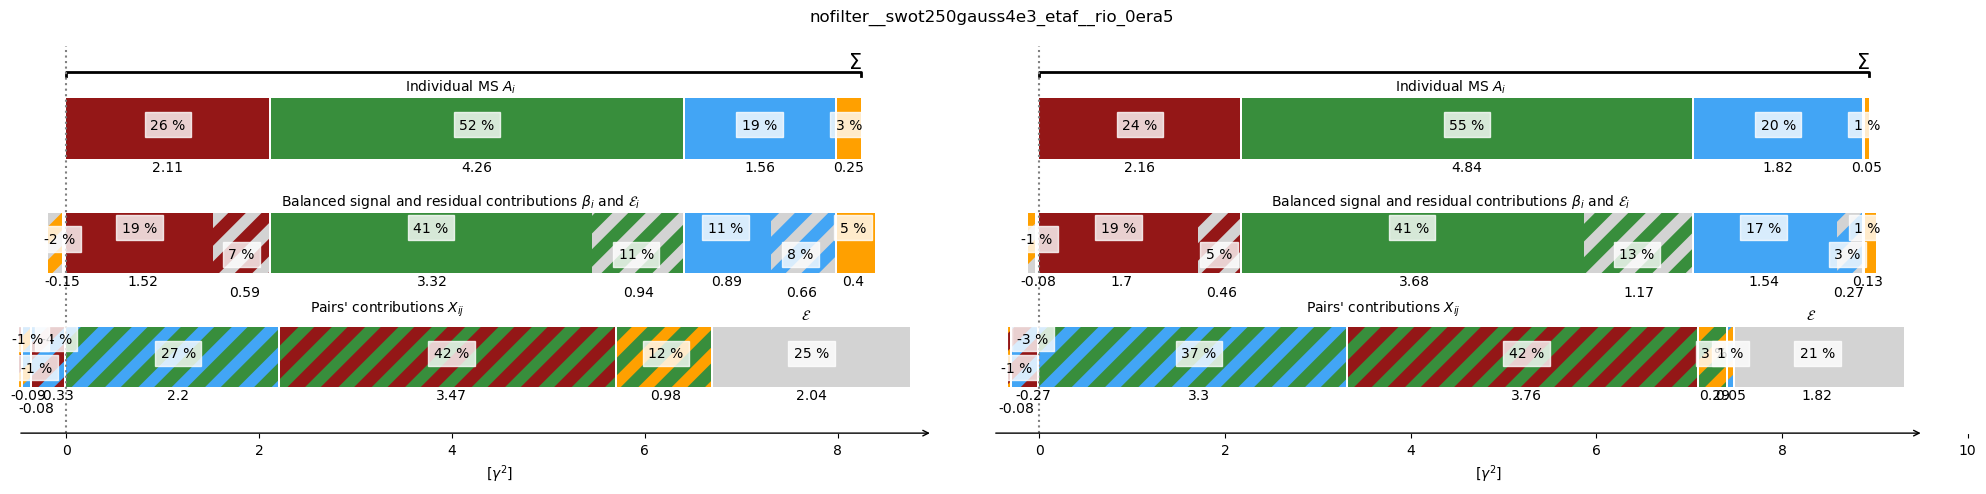

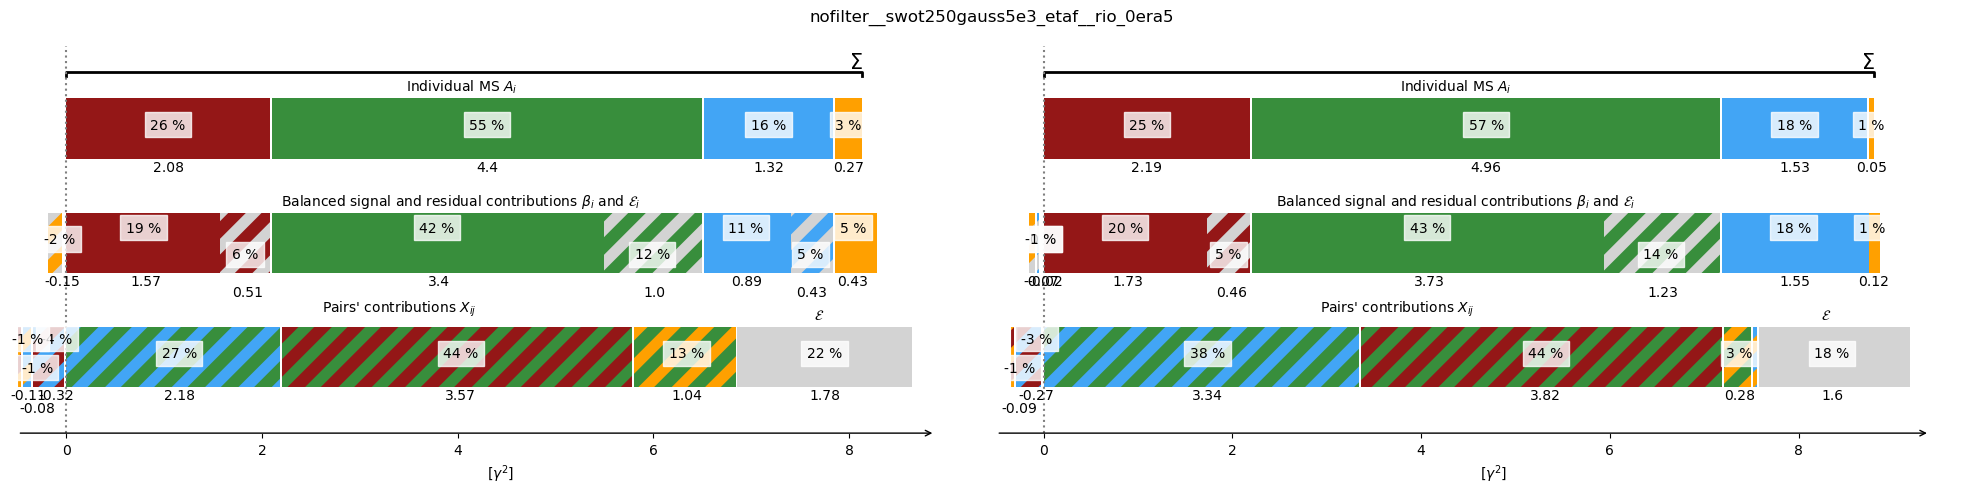

In [8]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss1e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss3e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss4e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'swot250gauss5e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0')]

DS = dataset_coloc_combs(comb_list, nearest =True)
DSS = DS.where(DS.depth==0, drop=True)
DSD = DS.where(DS.depth==15, drop=True)
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e')
    synthetic_figure(df.loc[c], axs[1], dir='n')
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

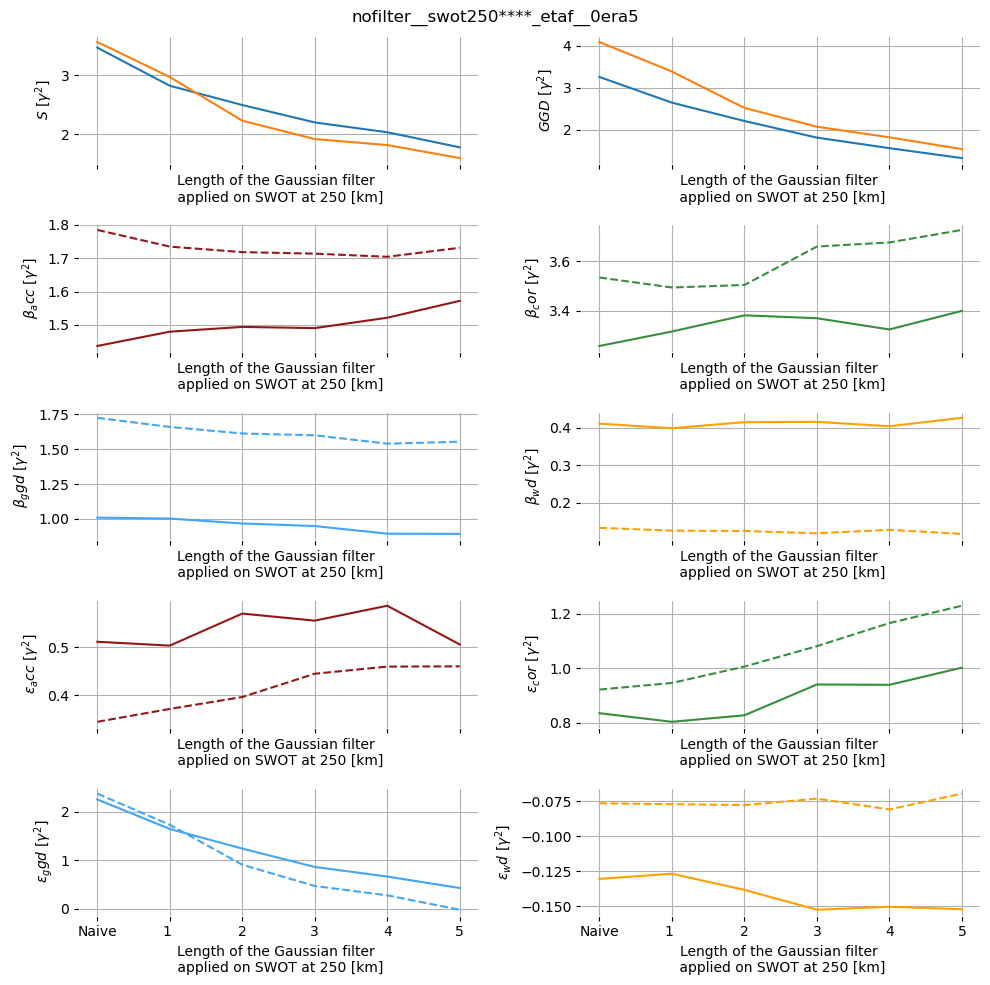

In [5]:
var= ['acc', 'cor', 'ggd', 'wd']
ds['id_comb']= ['Naive', '1 ', '2', '3', '4', '5']

fig, axs = plt.subplots(5,2, sharex=True, figsize = (10, 10))
axs =axs.flatten()

ax=axs[0]
ds.Se.plot(ax=ax)
ds.Sn.plot(ax=ax)
ax.set_ylabel(rf'$S$ [$\gamma^2$]')

ax=axs[1]
ds.GGDe.plot(ax=ax)
ds.GGDn.plot(ax=ax)
ax.set_ylabel(rf'$GGD$ [$\gamma^2$]')

for i in range(2, 6):
    v = var[i-2]
    ax=axs[i]
    ds['Be_'+v].plot(ax=ax, c=c0[v])
    ds['Bn_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\beta_{v}$ [$\gamma^2$]')

for i in range(6, 10):
    v = var[i-6]
    ax=axs[i]
    ds['Ee_'+v].plot(ax=ax, c=c0[v])
    ds['En_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\epsilon_{v}$ [$\gamma^2$]')
    
for ax in axs :
    ax.set_xlabel('Length of the Gaussian filter \n applied on SWOT at 250 [km]')
    ax.grid()
fig.suptitle('nofilter__swot250****_etaf__0era5')
fig.tight_layout()

In [6]:
ds

<xarray.Dataset> Size: 2kB
Dimensions:     (id_comb: 6)
Coordinates:
  * id_comb     (id_comb) <U5 120B 'Naive' '1 ' '2' '3' '4' '5'
Data variables: (12/41)
    ACCn        (id_comb) float64 48B 1.122 1.145 1.14 1.156 1.198 1.205
    CORn        (id_comb) float64 48B 2.954 2.97 2.978 3.044 3.225 3.369
    GGDn        (id_comb) float64 48B 110.3 57.36 15.02 7.065 4.034 2.779
    WDn         (id_comb) float64 48B 0.004063 0.004265 ... 0.004707 0.004984
    Sn          (id_comb) float64 48B 109.5 56.6 14.31 6.444 3.524 2.232
    ACCe        (id_comb) float64 48B 1.132 1.127 1.121 1.164 1.147 1.166
    ...          ...
    Xn_acc_cor  (id_comb) float64 48B 1.991 2.131 2.099 2.131 2.243 2.416
    Xn_acc_ggd  (id_comb) float64 48B -0.2157 -0.1701 ... -0.3773 -0.3912
    Xn_acc_wd   (id_comb) float64 48B -0.008133 -0.008084 ... -0.008751
    Xn_cor_ggd  (id_comb) float64 48B 3.065 2.904 2.909 2.88 3.032 3.064
    Xn_cor_wd   (id_comb) float64 48B 0.03382 0.03408 ... 0.03804 0.04655
    Xn_ggd_wd   (id_comb) float64 48B -0.03095 -0.01528 ... 0.006423 -0.000745

______
# Sensitivity of SWOT 250m 2e3 to the drifter filter

nofilter__swot250gauss2e3_etaf__rio_0era5
0.5cpd__swot250gauss2e3_etaf__rio_0era5
1.5cpd__swot250gauss2e3_etaf__rio_0era5
2.5cpd__swot250gauss2e3_etaf__rio_0era5
3cpd__swot250gauss2e3_etaf__rio_0era5
10.469307603939153
10.921079217779265
19.20159519152587
19.6732364556948
8.460066715593825
8.726904338552252
16.890925120677622
17.19110657847488
9.85375520472847
10.360458735889857
18.44310925613379
18.92485283403744
10.13879816466002
10.645896976674015
18.990823912684984
19.566882795967533
10.223204418598922
10.7550308133016
19.10226454878441
19.65056575968077


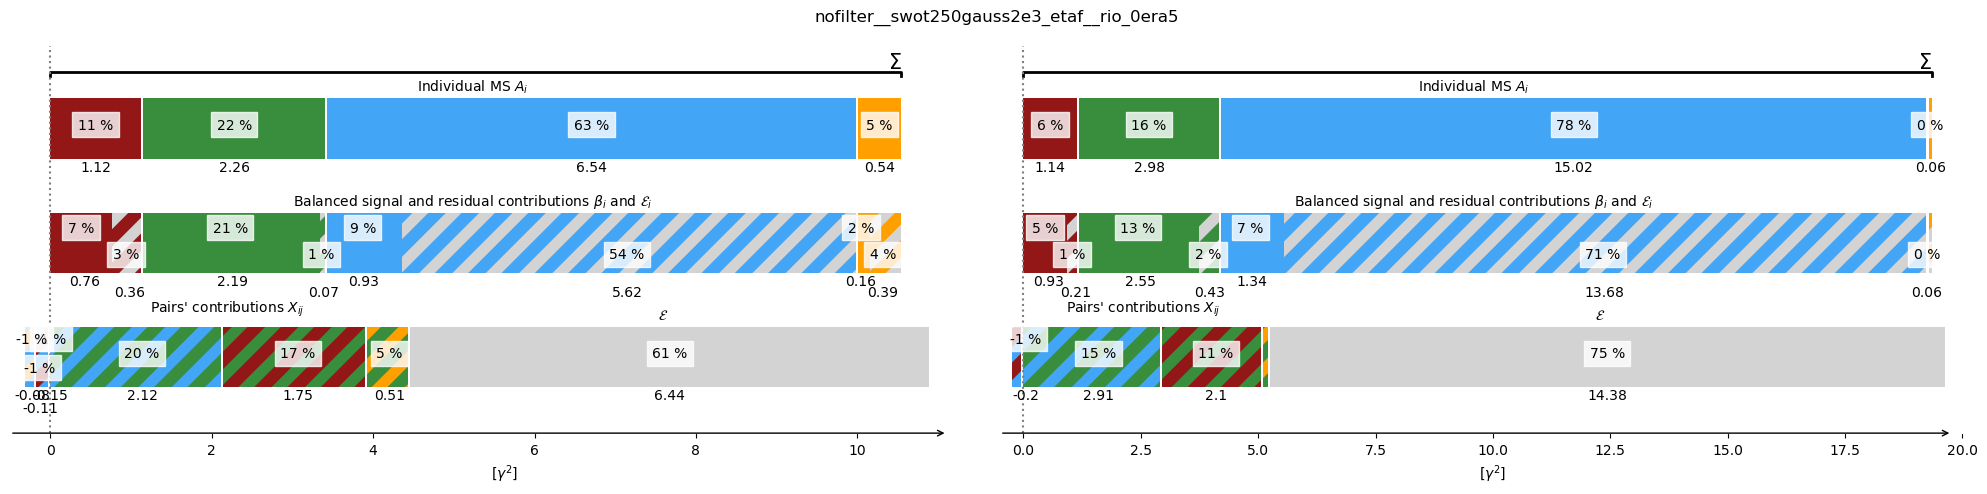

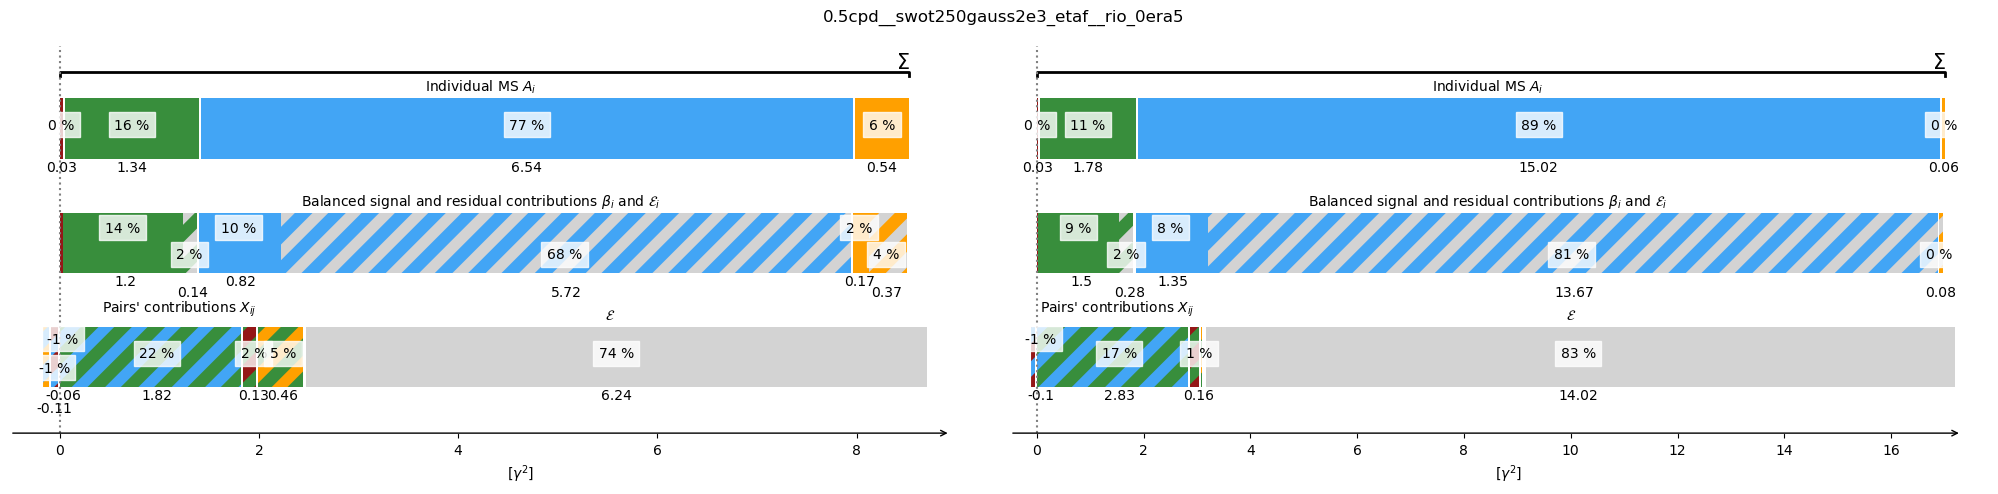

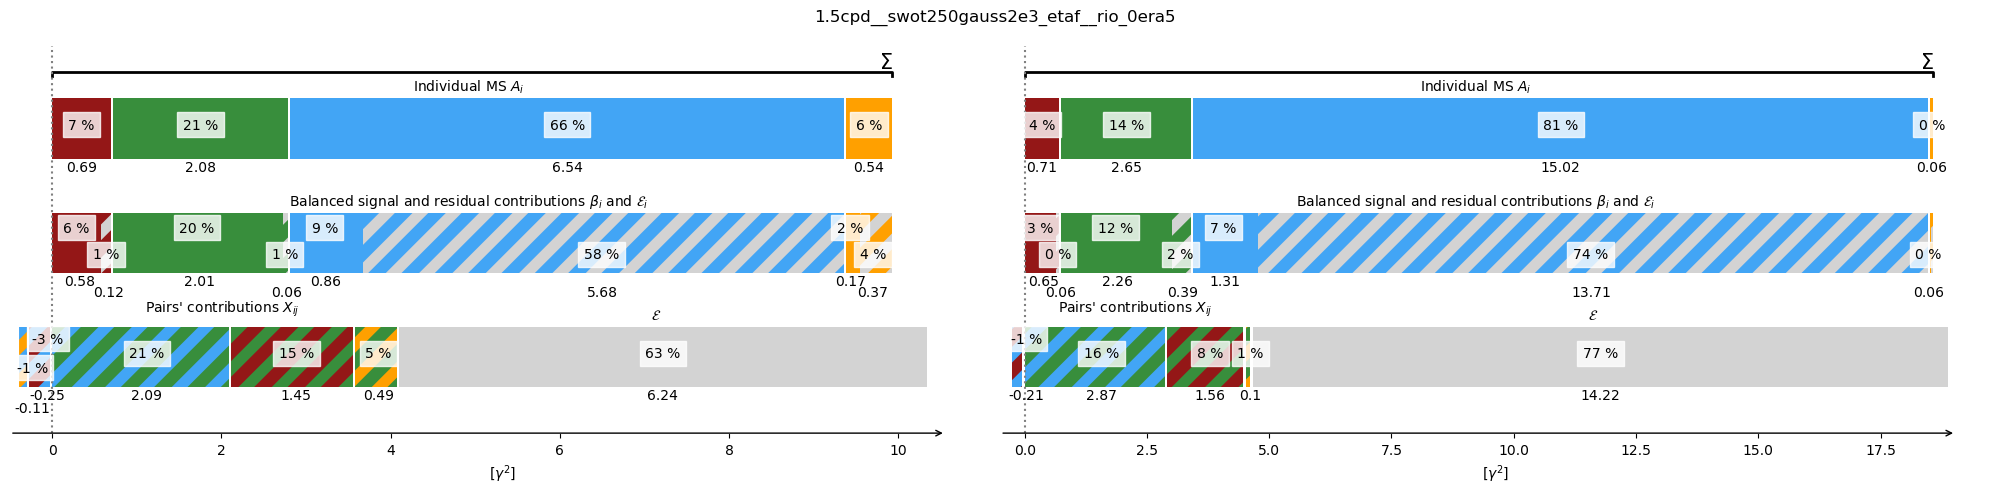

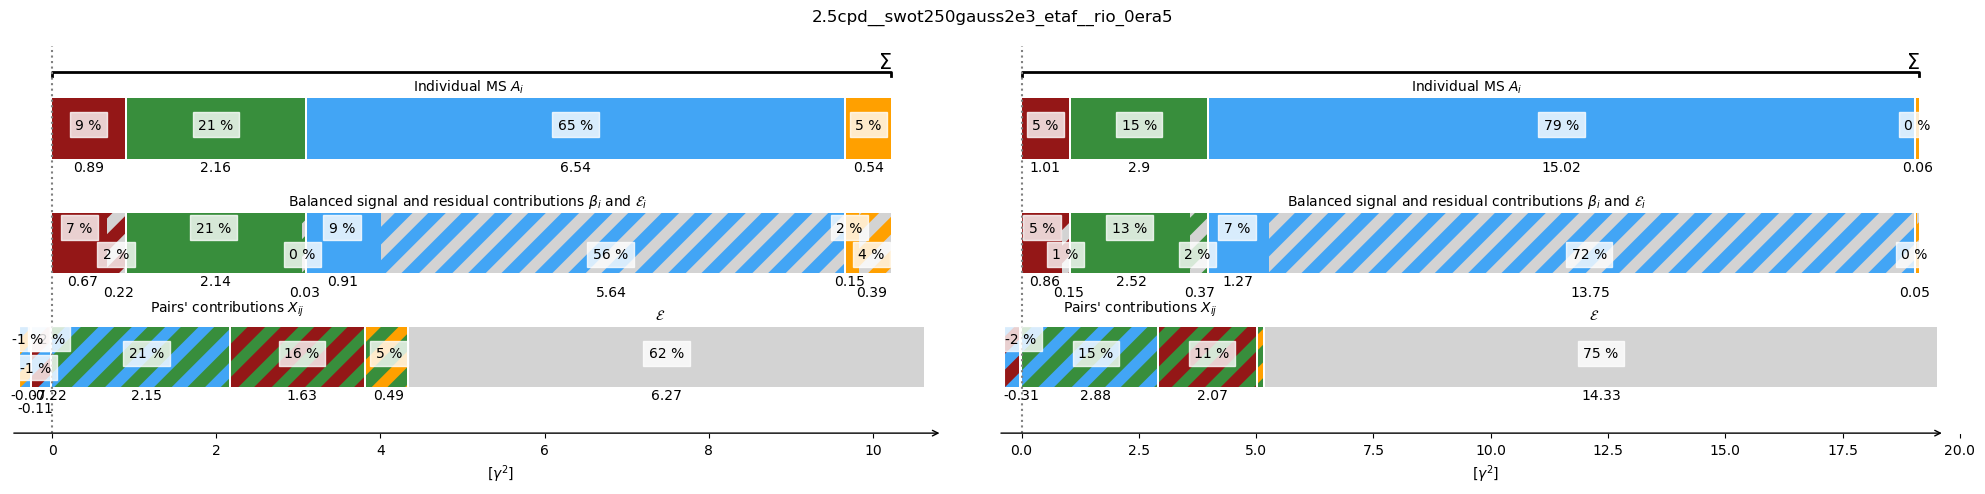

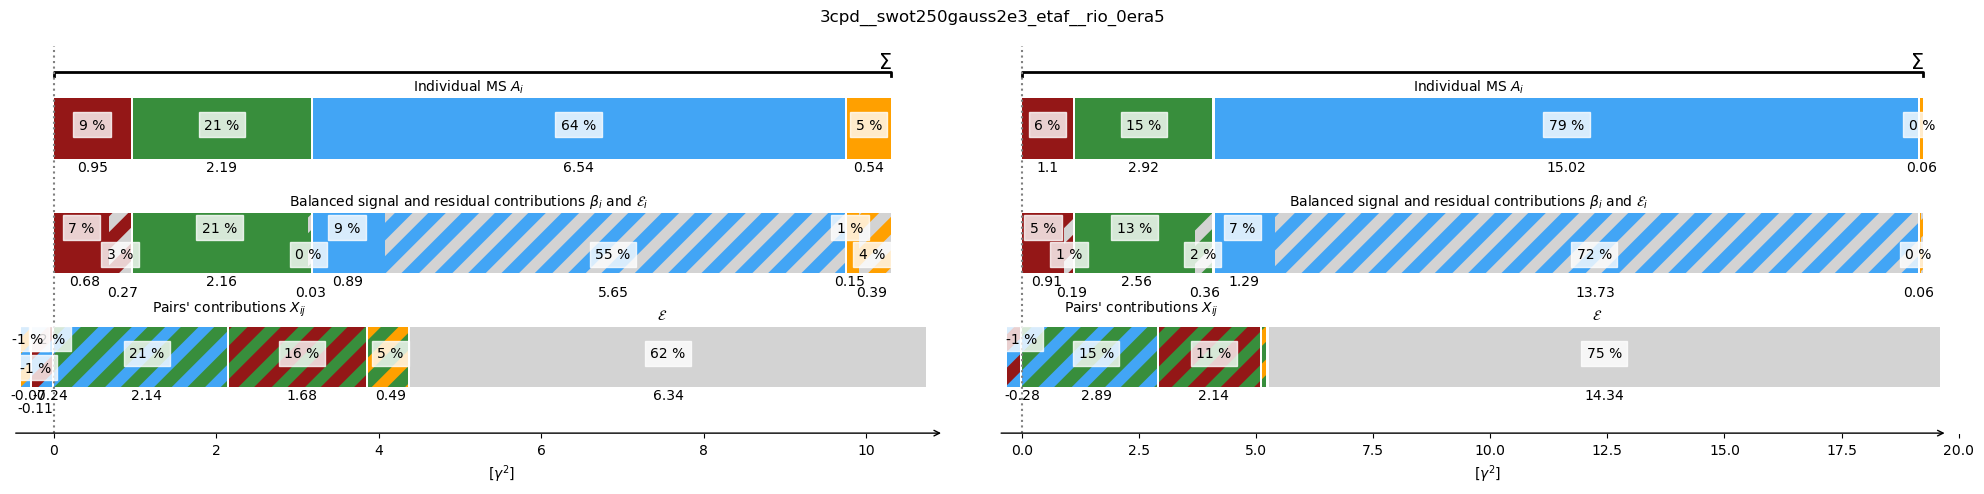

In [6]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='0.5cpd', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='1.5cpd', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='2.5cpd', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='3cpd', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             ]

DS = dataset_coloc_combs(comb_list, nearest =True)
DSS = DS.where(DS.depth==0, drop=True)
DSD = DS.where(DS.depth==15, drop=True)
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e')
    synthetic_figure(df.loc[c], axs[1], dir='n')
    fig.suptitle(c)
    fig.tight_layout()

In [114]:
DS.ggde.var('row_number')/U2

<xarray.DataArray 'ggde' (id_comb: 6)> Size: 48B
array([12.00827648,  5.68351449,  4.17799982,  3.07795608,  1.90902055,
        1.38092692])
Coordinates:
  * id_comb  (id_comb) <U38 912B 'nofilter__swot250naive_etaf__15era5' ... 'n...

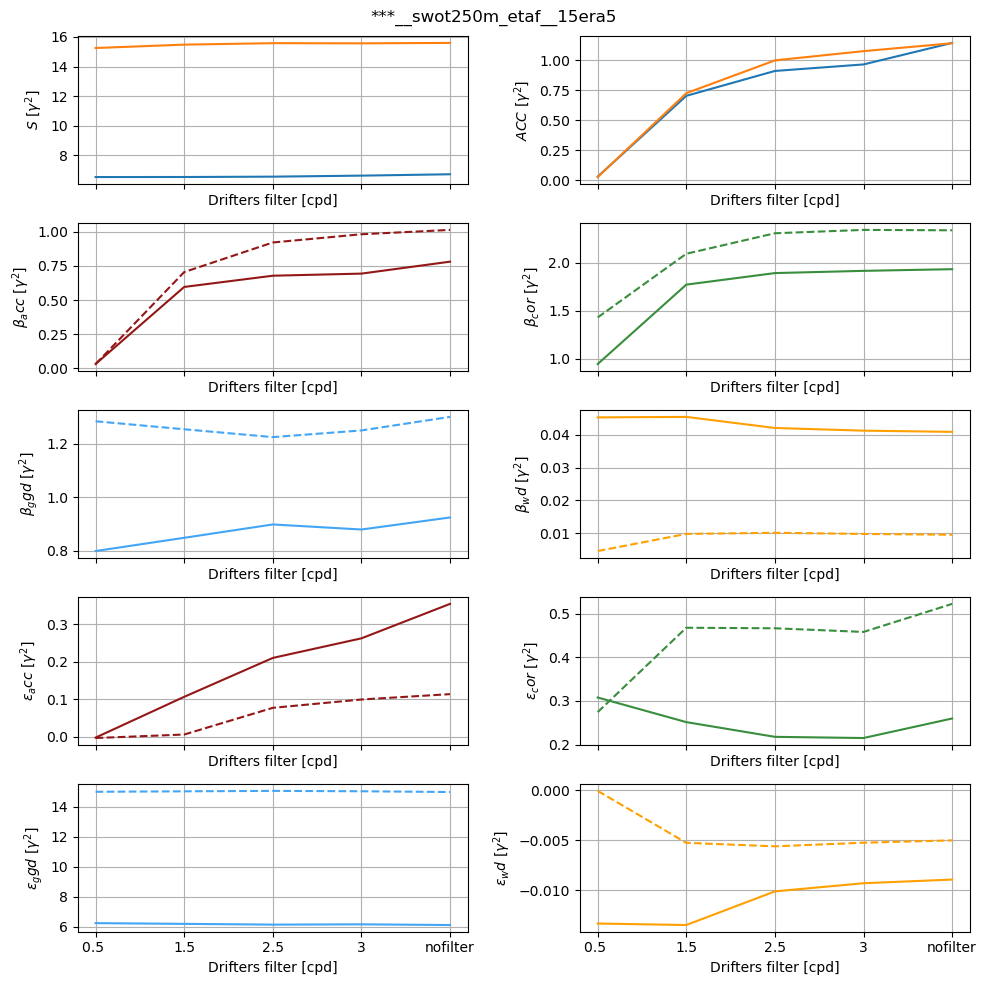

In [85]:
var= ['acc', 'cor', 'ggd', 'wd']
if not 'nofilter' in ds.id_comb :
    ds['id_comb']= ['nofilter', '0.5 ', '1.5', '2.5', '3']
    ds = ds.sortby('id_comb', ['0.5 ', '1.5', '2.5', '3', 'no_filter'])

fig, axs = plt.subplots(5,2, sharex=True, figsize = (10, 10))
axs =axs.flatten()

ax=axs[0]
ds.Se.plot(ax=ax)
ds.Sn.plot(ax=ax)
ax.set_ylabel(rf'$S$ [$\gamma^2$]')

ax=axs[1]
ds.ACCe.plot(ax=ax)
ds.ACCn.plot(ax=ax)
ax.set_ylabel(rf'$ACC$ [$\gamma^2$]')

for i in range(2, 6):
    v = var[i-2]
    ax=axs[i]
    ds['Be_'+v].plot(ax=ax, c=c0[v])
    ds['Bn_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\beta_{v}$ [$\gamma^2$]')

for i in range(6, 10):
    v = var[i-6]
    ax=axs[i]
    ds['Ee_'+v].plot(ax=ax, c=c0[v])
    ds['En_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\epsilon_{v}$ [$\gamma^2$]')
    
for ax in axs :
    ax.set_xlabel('Drifters filter [cpd]')
    ax.grid()
fig.suptitle('***__swot250m_etaf__15era5')
fig.tight_layout()

________________
# SWOT 2km filter on alti ?

nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmgauss1e3_etaf__rio_0era5
nofilter__swot2kmgauss2e3_etaf__rio_0era5
nofilter__swot2kmgauss3e3_etaf__rio_0era5
nofilter__swot2kmgauss4e3_etaf__rio_0era5
nofilter__swot2kmgauss5e3_etaf__rio_0era5
7.955265457422579
8.548933881003055
8.724251506452022
9.053795196861604
7.559149061352902
8.08264639622219
8.031488499215591
8.317070020594638
7.918255585161937
8.512037352681059
8.679963433331977
9.082692308546674
8.02059315494789
8.661816166576699
8.675976843498985
9.205692659009657
7.873184250575856
8.469927815594055
8.825799127676976
9.35899782984282
7.749638717189307
8.416143625799215
8.809995947143484
9.287223539312645


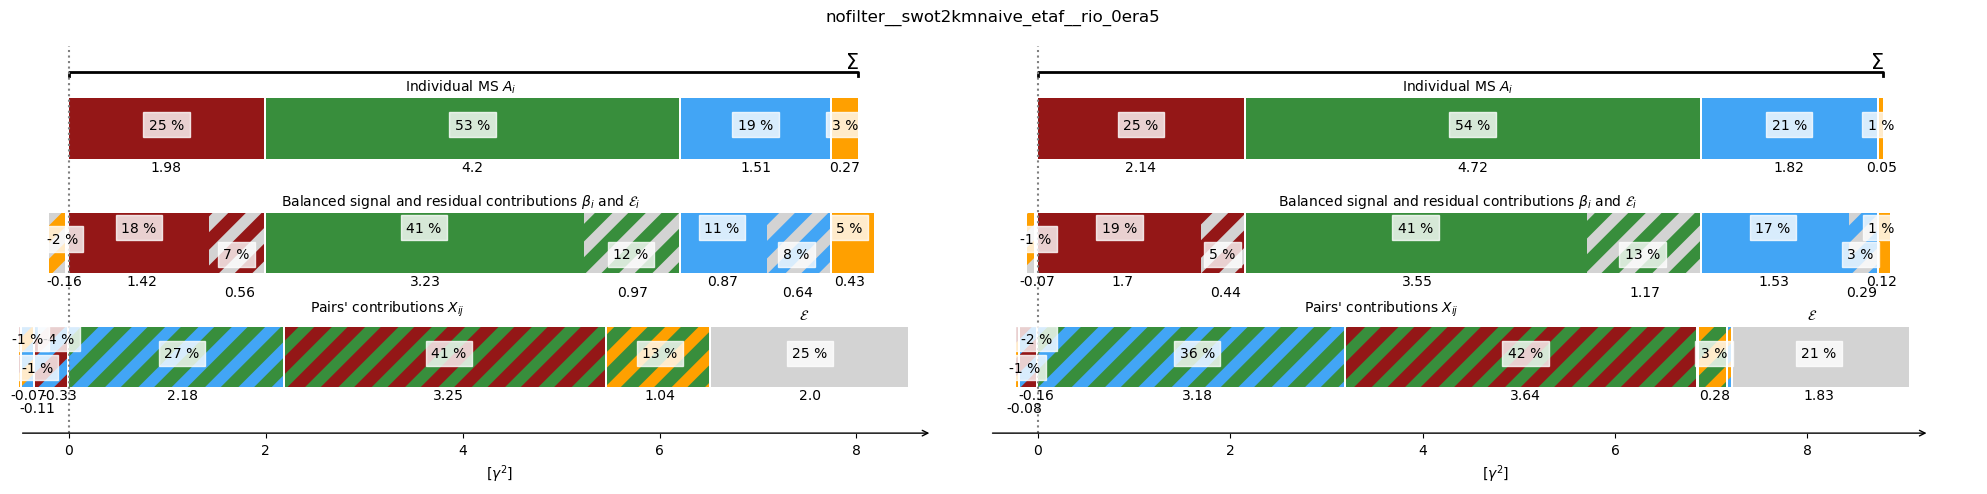

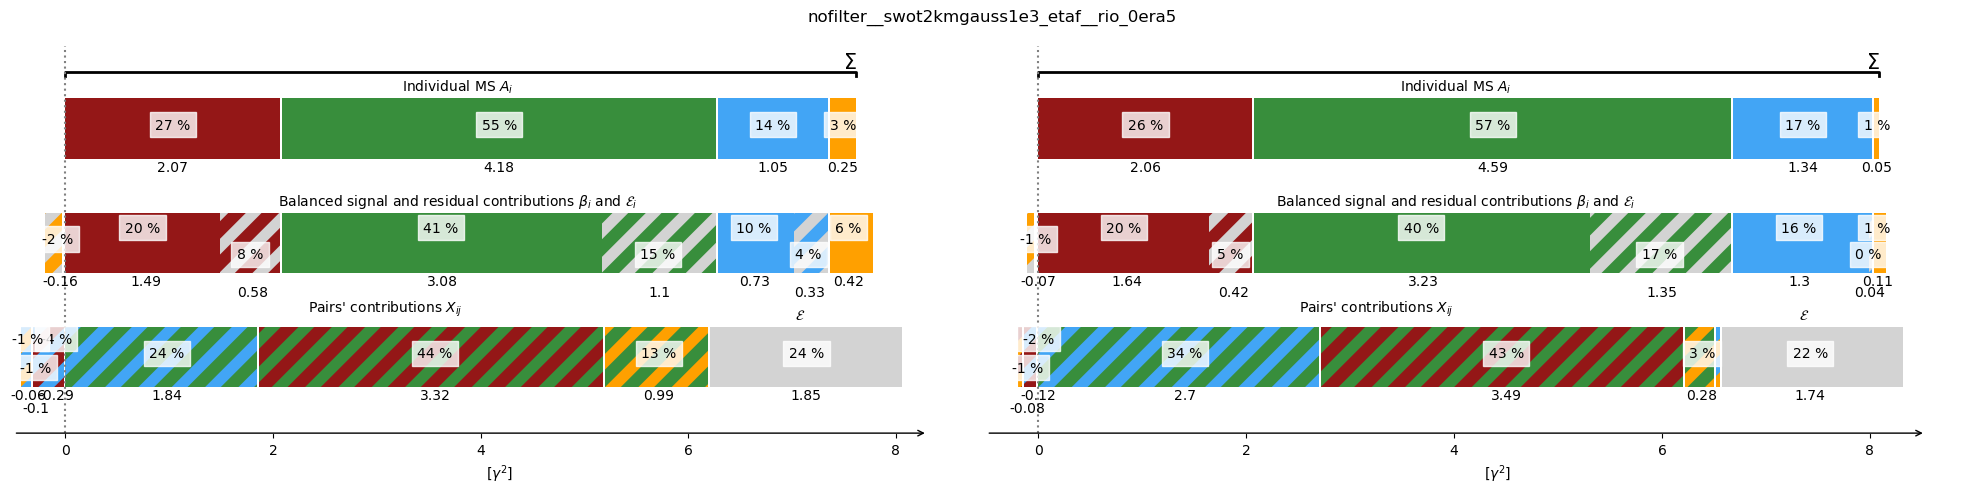

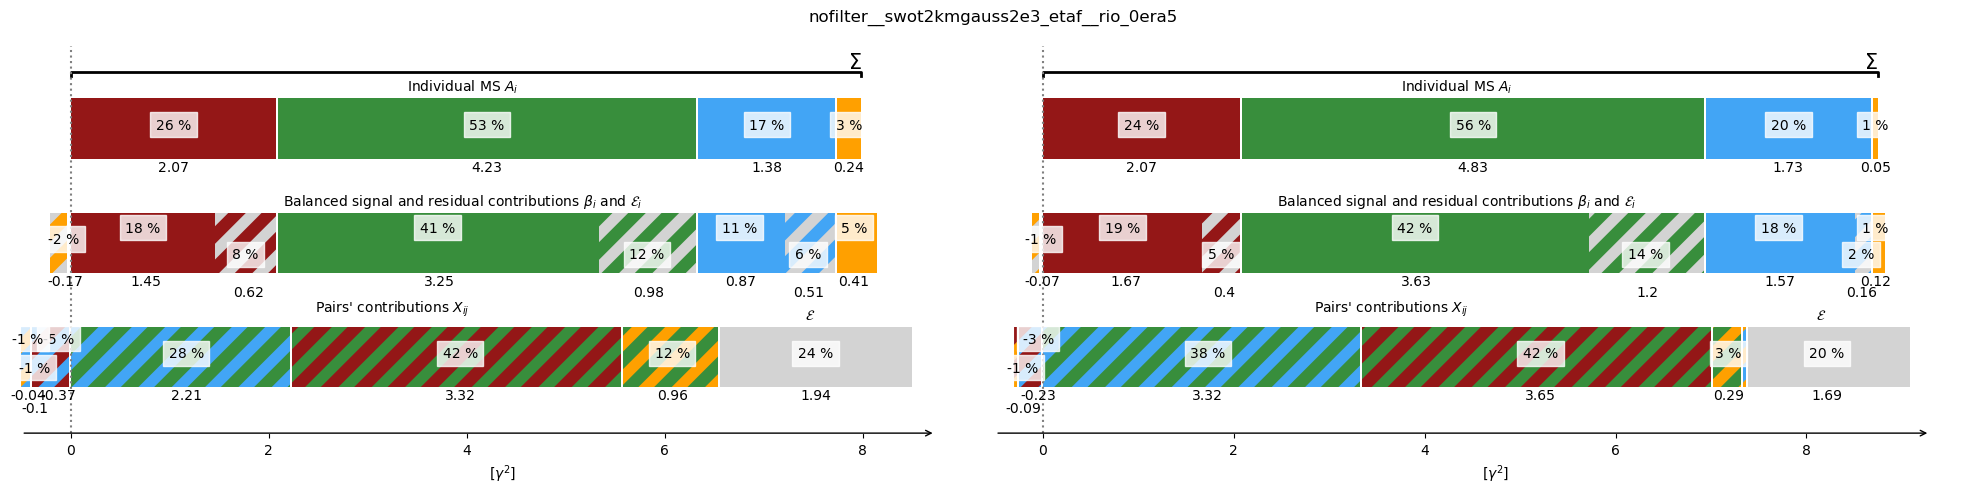

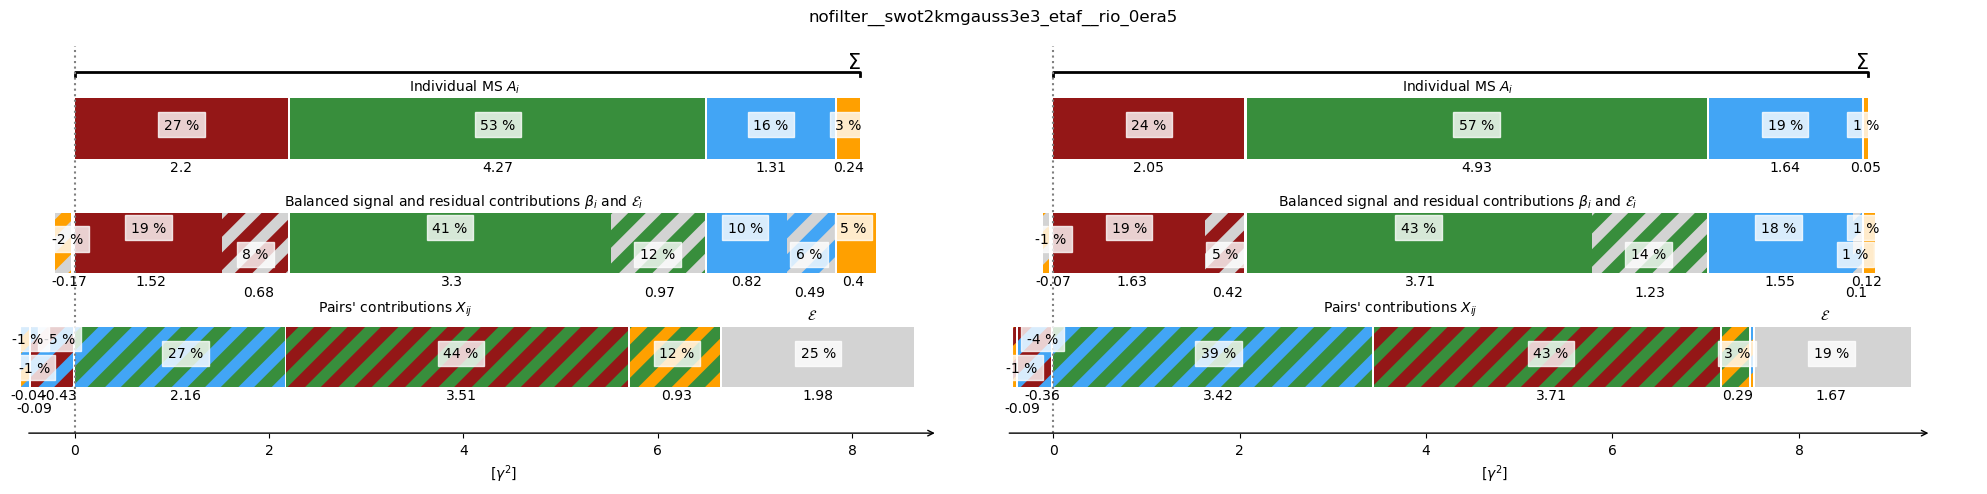

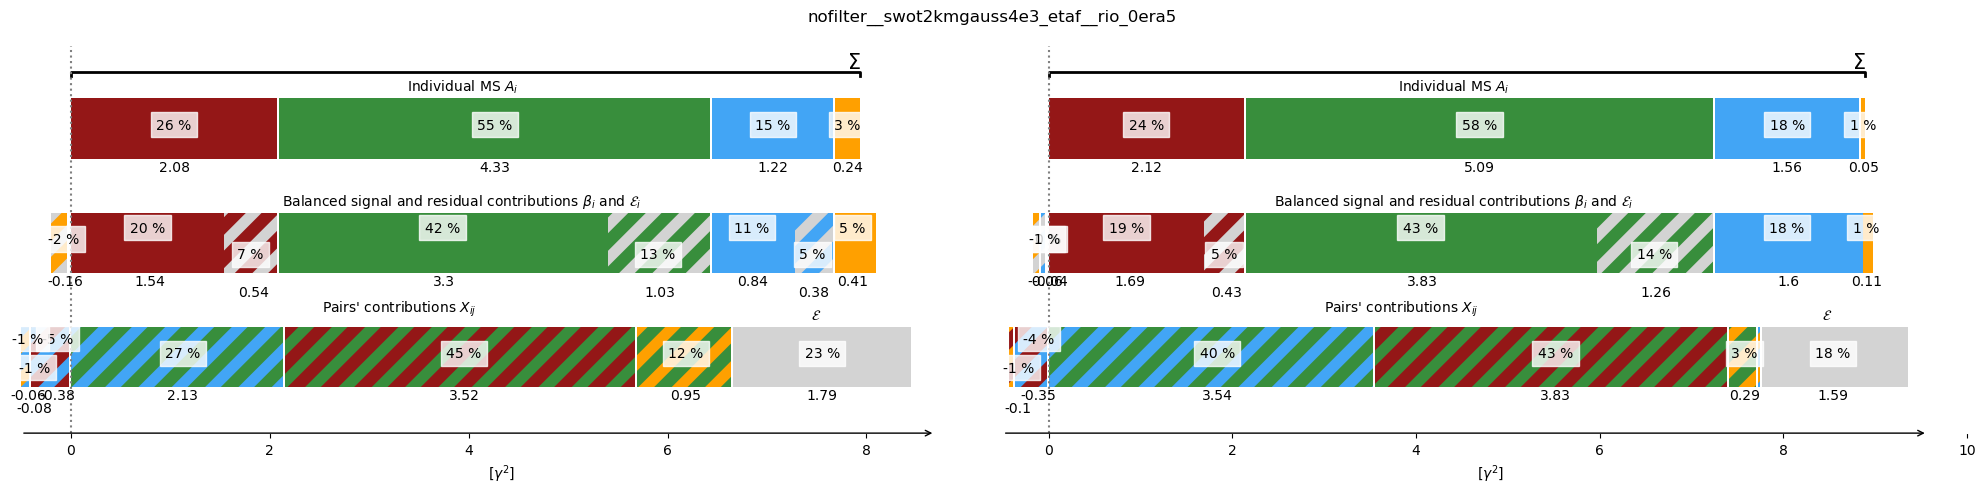

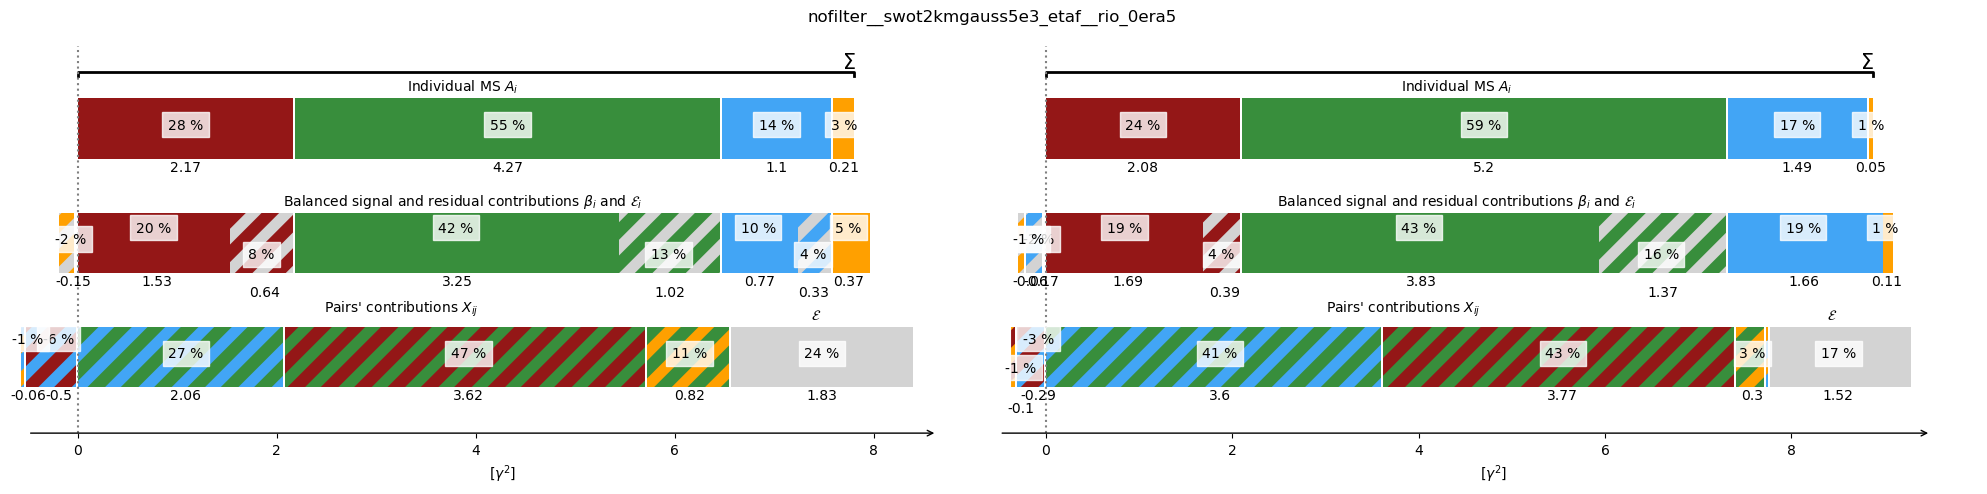

In [10]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot2kmgauss1e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot2kmgauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot2kmgauss3e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot2kmgauss4e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'swot2kmgauss5e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0')]

DS = dataset_coloc_combs(comb_list, nearest =True)
DSS = DS.where(DS.depth==0, drop=True)
DSD = DS.where(DS.depth==15, drop=True)
ds = compute_mean_square(DSS)/U2

df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e')
    synthetic_figure(df.loc[c], axs[1], dir='n')
    fig.suptitle(c)
    fig.tight_layout()

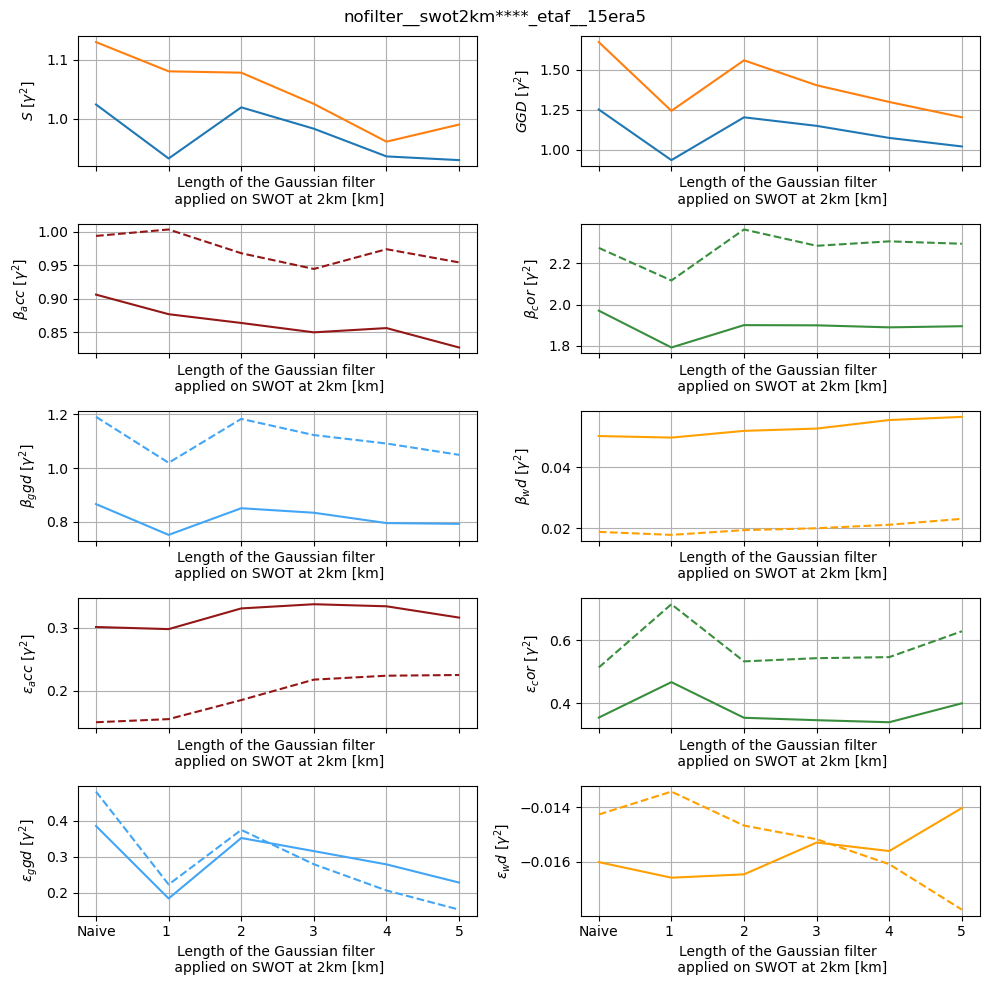

In [82]:
var= ['acc', 'cor', 'ggd', 'wd']
ds['id_comb']= ['Naive', '1 ', '2', '3', '4', '5']

fig, axs = plt.subplots(5,2, sharex=True, figsize = (10, 10))
axs =axs.flatten()

ax=axs[0]
ds.Se.plot(ax=ax)
ds.Sn.plot(ax=ax)
ax.set_ylabel(rf'$S$ [$\gamma^2$]')

ax=axs[1]
ds.GGDe.plot(ax=ax)
ds.GGDn.plot(ax=ax)
ax.set_ylabel(rf'$GGD$ [$\gamma^2$]')

for i in range(2, 6):
    v = var[i-2]
    ax=axs[i]
    ds['Be_'+v].plot(ax=ax, c=c0[v])
    ds['Bn_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\beta_{v}$ [$\gamma^2$]')

for i in range(6, 10):
    v = var[i-6]
    ax=axs[i]
    ds['Ee_'+v].plot(ax=ax, c=c0[v])
    ds['En_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\epsilon_{v}$ [$\gamma^2$]')
    
for ax in axs :
    ax.set_xlabel('Length of the Gaussian filter \n applied on SWOT at 2km [km]')
    ax.grid()
fig.suptitle('nofilter__swot2km****_etaf__15era5')
fig.tight_layout()

________________
# SWOT 2km filter on alti ?

nofilter__swot2kmnaive_etaf__15era5
0.5cpd__swot2kmnaive_etaf__15era5
1.5cpd__swot2kmnaive_etaf__15era5
2.5cpd__swot2kmnaive_etaf__15era5
3cpd__swot2kmnaive_etaf__15era5
4.703765021005737
4.723696715174654
5.802999586533861
5.654425985020742
2.638931893009576
2.619801405128777
3.479984993090941
3.313103821975629
4.074518480245626
4.06785156299007
5.1061859638469915
4.9669529500512875
4.397584362151594
4.4157439582370195
5.566658286742149
5.409780000591289
4.469341029616347
4.49206402610177
5.670734941655143
5.51575962108344


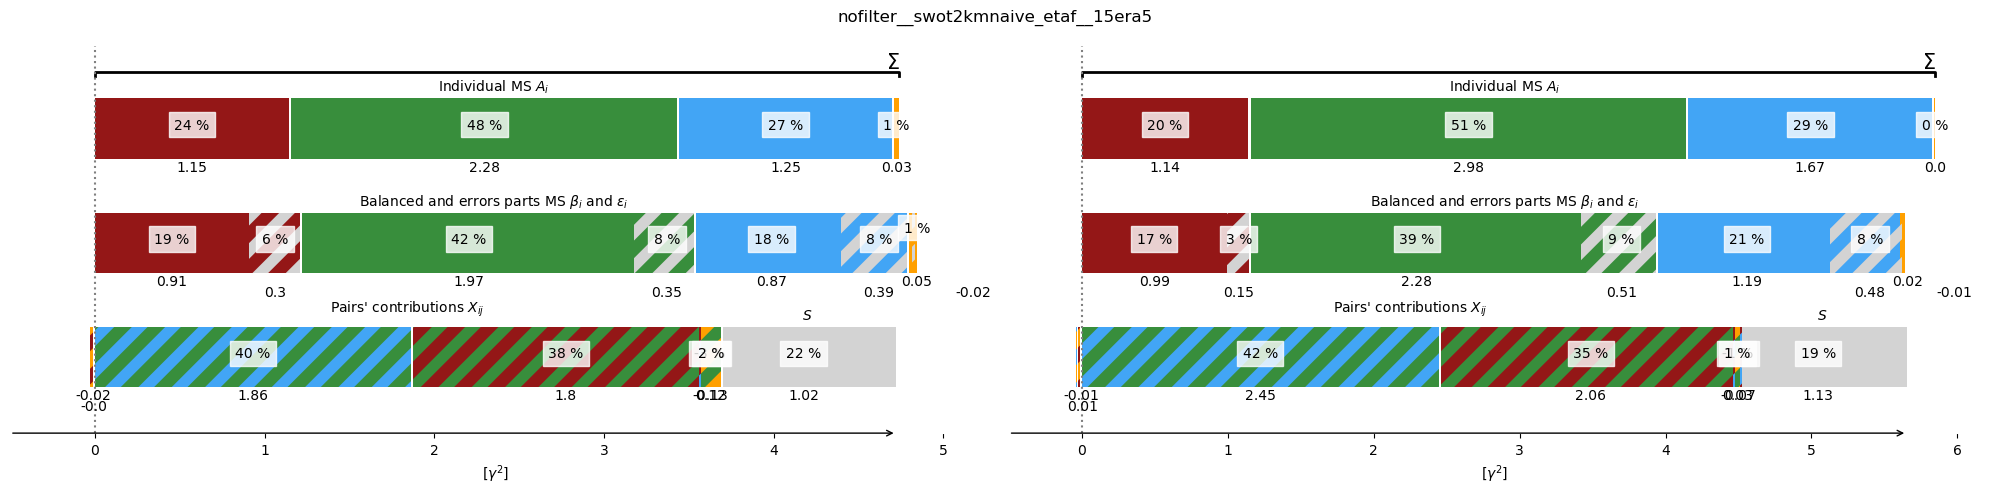

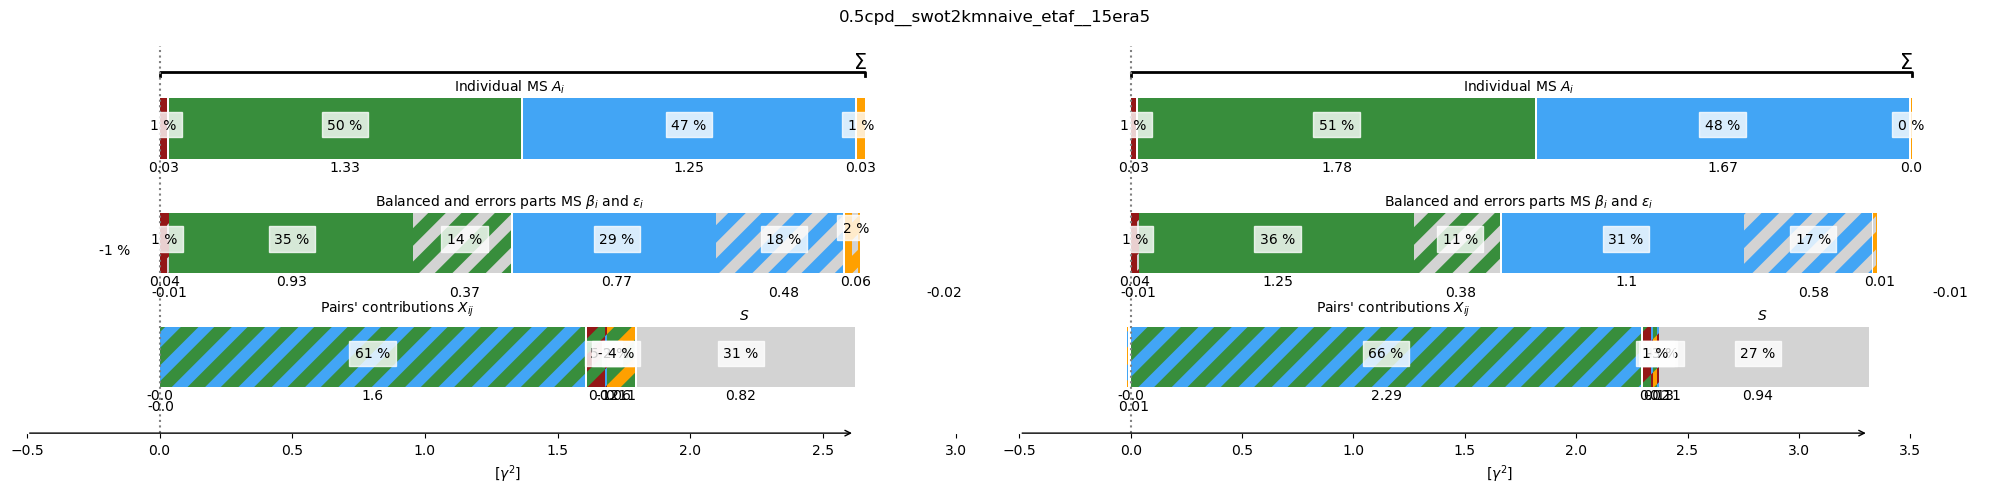

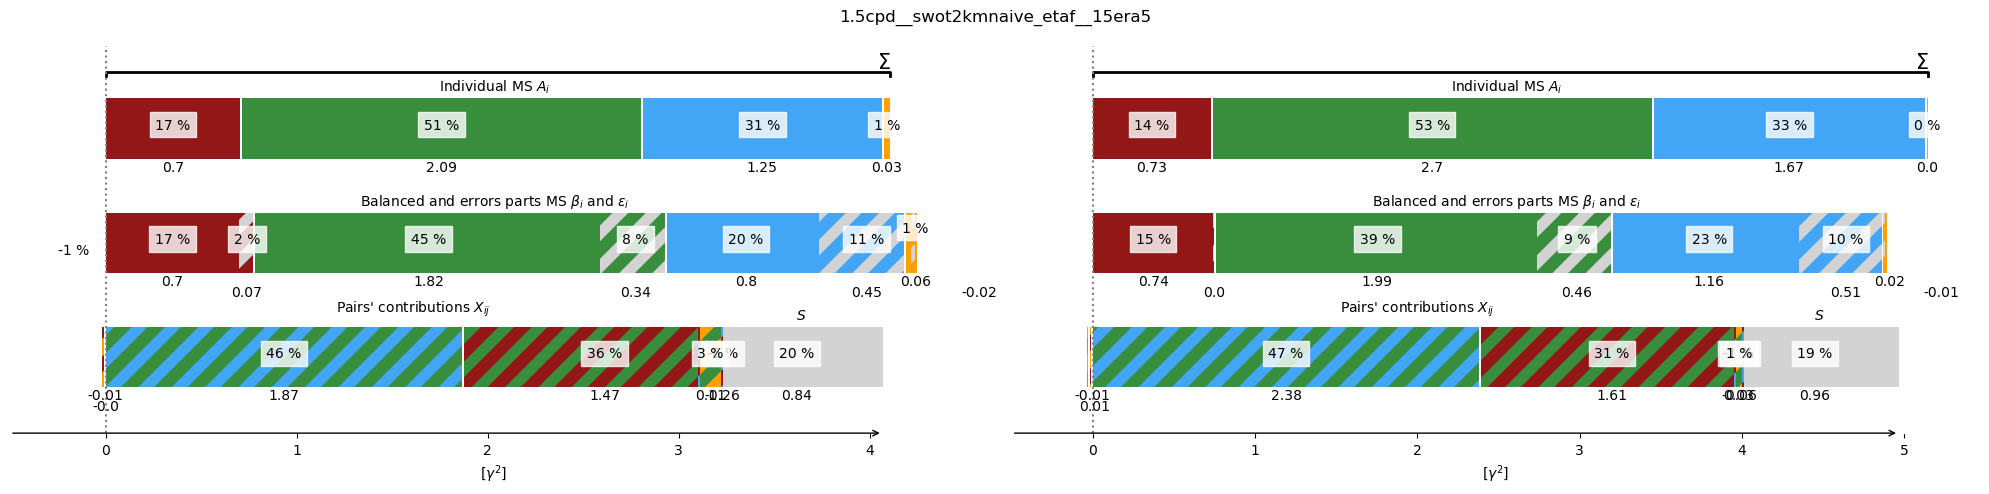

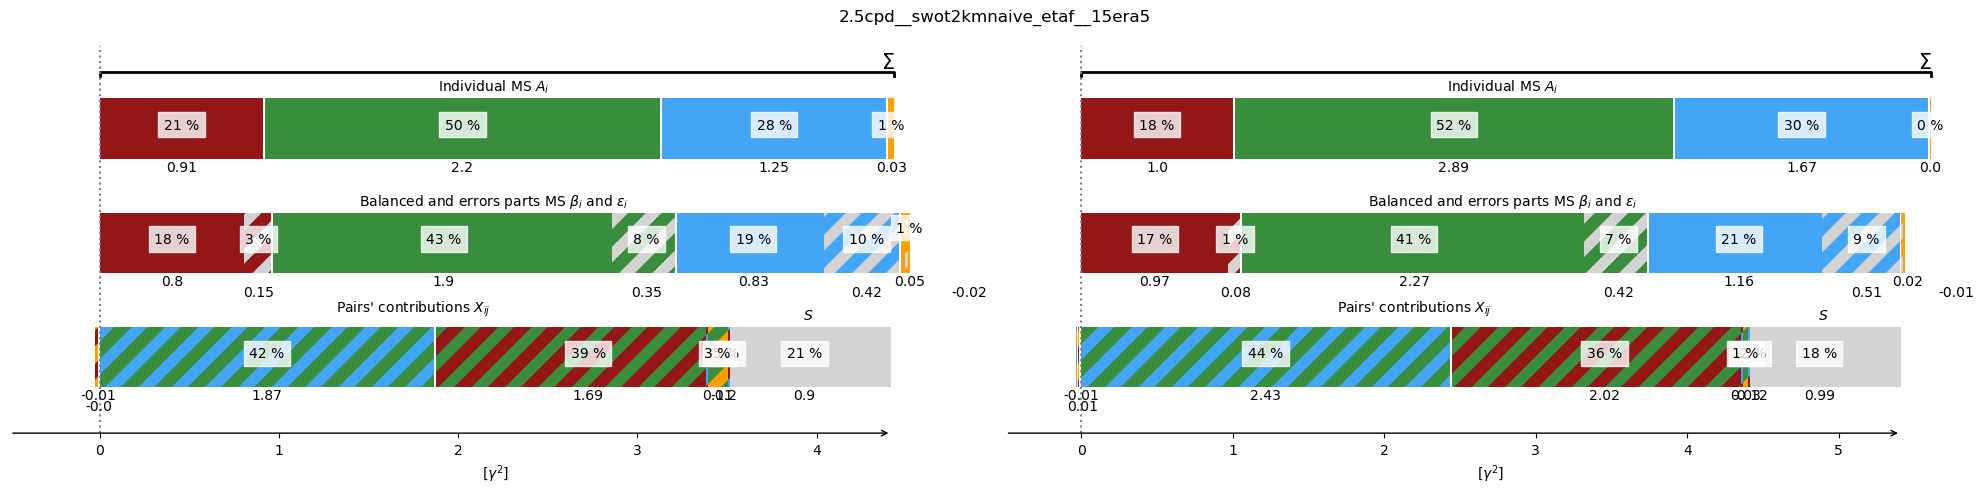

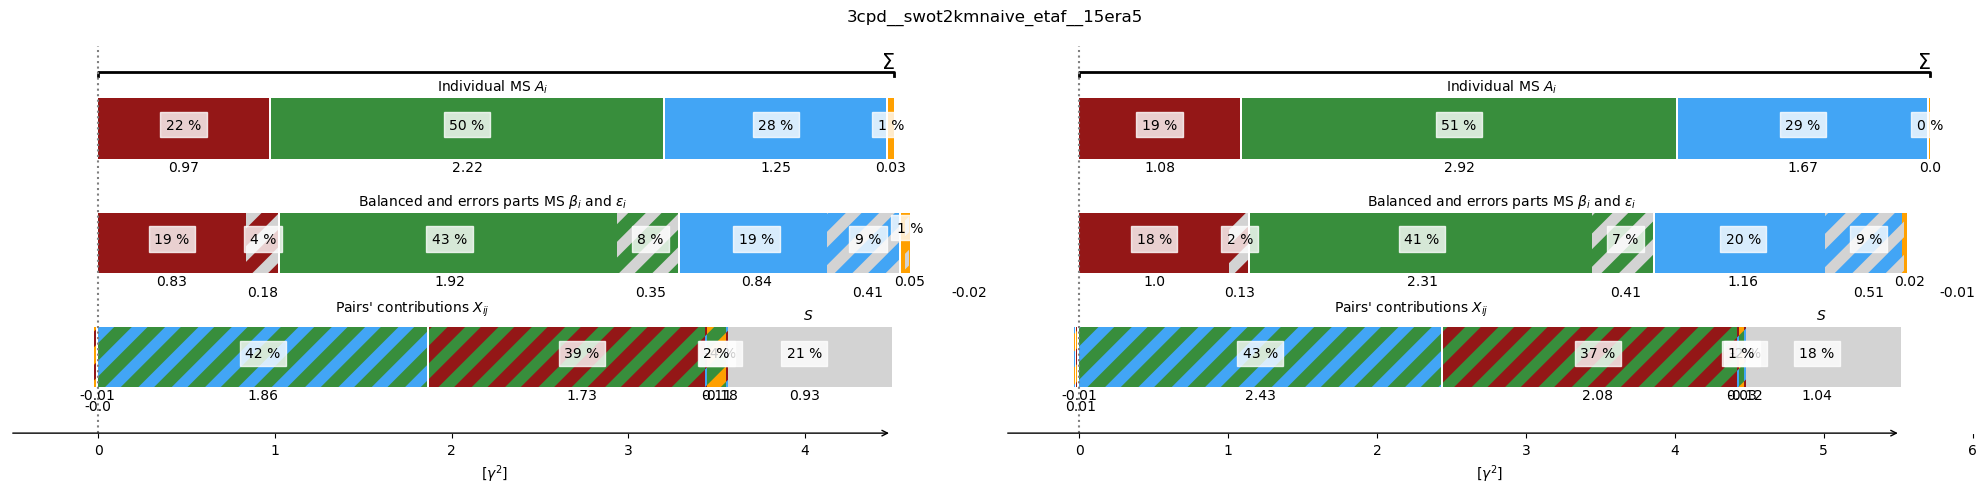

In [106]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='0.5cpd', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='1.5cpd', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='2.5cpd', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='3cpd', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             ]

DS = dataset_coloc_combs(comb_list, nearest =True)
DSS = DS.where(DS.depth==0, drop=True)
DSD = DS.where(DS.depth==15, drop=True)
ds = compute_mean_square(DSD)/U2

df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e')
    synthetic_figure(df.loc[c], axs[1], dir='n')
    fig.suptitle(c)
    fig.tight_layout()

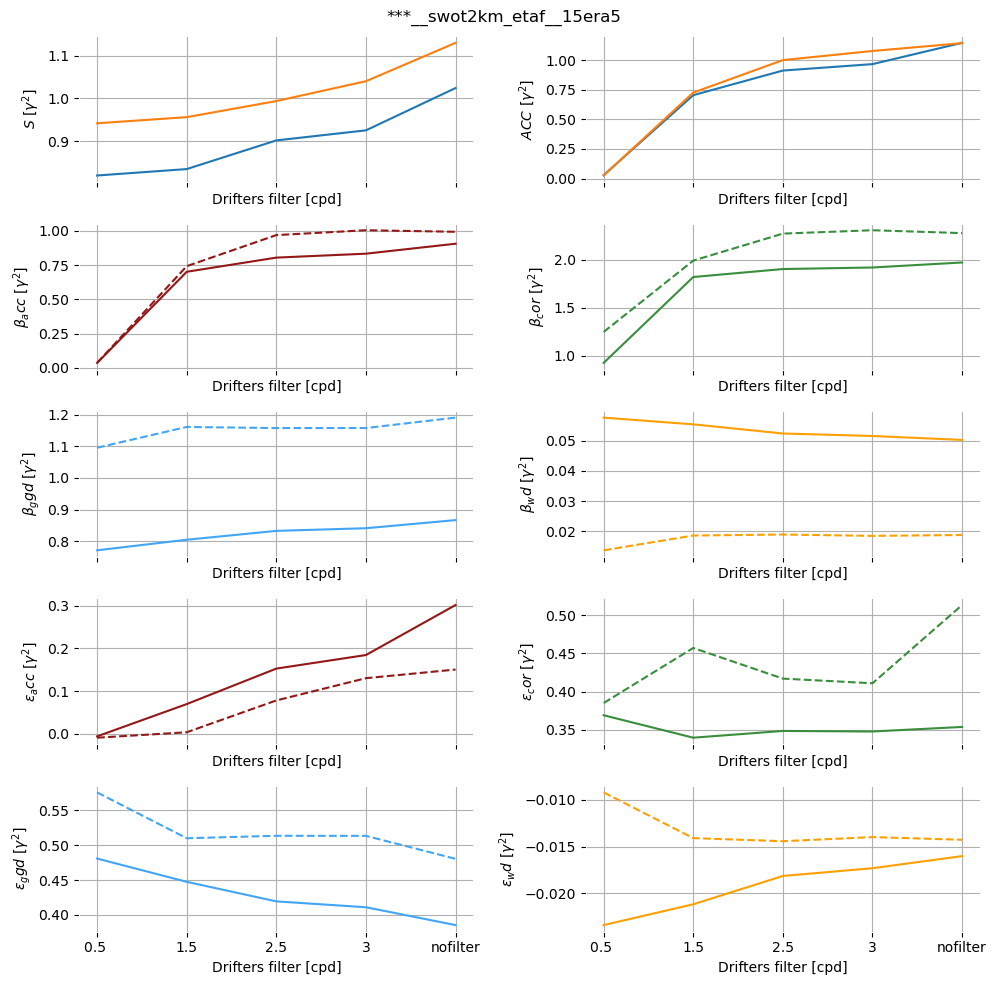

In [107]:
var= ['acc', 'cor', 'ggd', 'wd']
if not 'nofilter' in ds.id_comb :
    ds['id_comb']= ['nofilter', '0.5 ', '1.5', '2.5', '3']
    ds = ds.sortby('id_comb', ['0.5 ', '1.5', '2.5', '3', 'no_filter'])

fig, axs = plt.subplots(5,2, sharex=True, figsize = (10, 10))
axs =axs.flatten()

ax=axs[0]
ds.Se.plot(ax=ax)
ds.Sn.plot(ax=ax)
ax.set_ylabel(rf'$S$ [$\gamma^2$]')

ax=axs[1]
ds.ACCe.plot(ax=ax)
ds.ACCn.plot(ax=ax)
ax.set_ylabel(rf'$ACC$ [$\gamma^2$]')

for i in range(2, 6):
    v = var[i-2]
    ax=axs[i]
    ds['Be_'+v].plot(ax=ax, c=c0[v])
    ds['Bn_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\beta_{v}$ [$\gamma^2$]')

for i in range(6, 10):
    v = var[i-6]
    ax=axs[i]
    ds['Ee_'+v].plot(ax=ax, c=c0[v])
    ds['En_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\epsilon_{v}$ [$\gamma^2$]')
    
for ax in axs :
    ax.set_xlabel('Drifters filter [cpd]')
    ax.grid()
fig.suptitle('***__swot2km_etaf__15era5')
fig.tight_layout()

# Visualization

In [ ]:
ds__= DS.sel(id_comb = 'etaf_swot250gauss1e3__15era5').isel(row_number=slice(20,40))
fig, ax = plt.subplots()
s = 3e-4
ds__.plot.quiver('longitude', 'latitude', 'acce', 'accn', color =c0['acc'], pivot='tail', scale=s )
ds__.plot.quiver('longitude', 'latitude', 'core', 'corn', color =c0['cor'],pivot='tail', scale=s )
ds__.plot.quiver('longitude', 'latitude', 'ggde', 'ggdn', color =c0['ggd'],pivot='tail', scale=s )
ds__.plot.quiver('longitude', 'latitude', 'wde', 'wdn', color =c0['wd'],pivot='tail', scale=s)
ds__.plot.quiver('longitude', 'latitude', 'sume', 'sumn', color ='k', pivot='tail', scale=s )

# Old Swot filtrage

5.827464383027202
5.968887558142416
7.815631173954805
7.8968408696419905
5.585850209282852
5.719890646854031
7.370497780005536
7.445348371633019
5.585850209282852
5.719890646854031
7.370497780005536
7.445348371633019
4.633770664425903
4.73958974547408
6.202247339303583
6.2623602785133


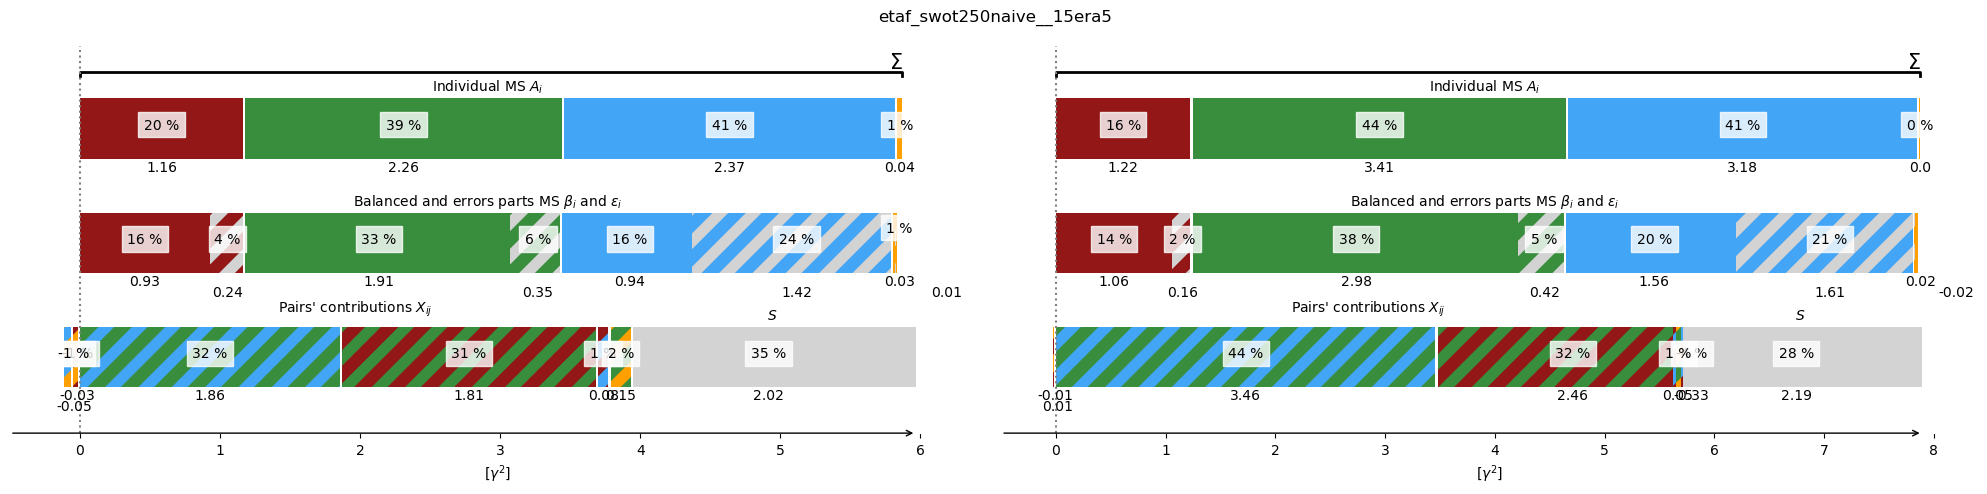

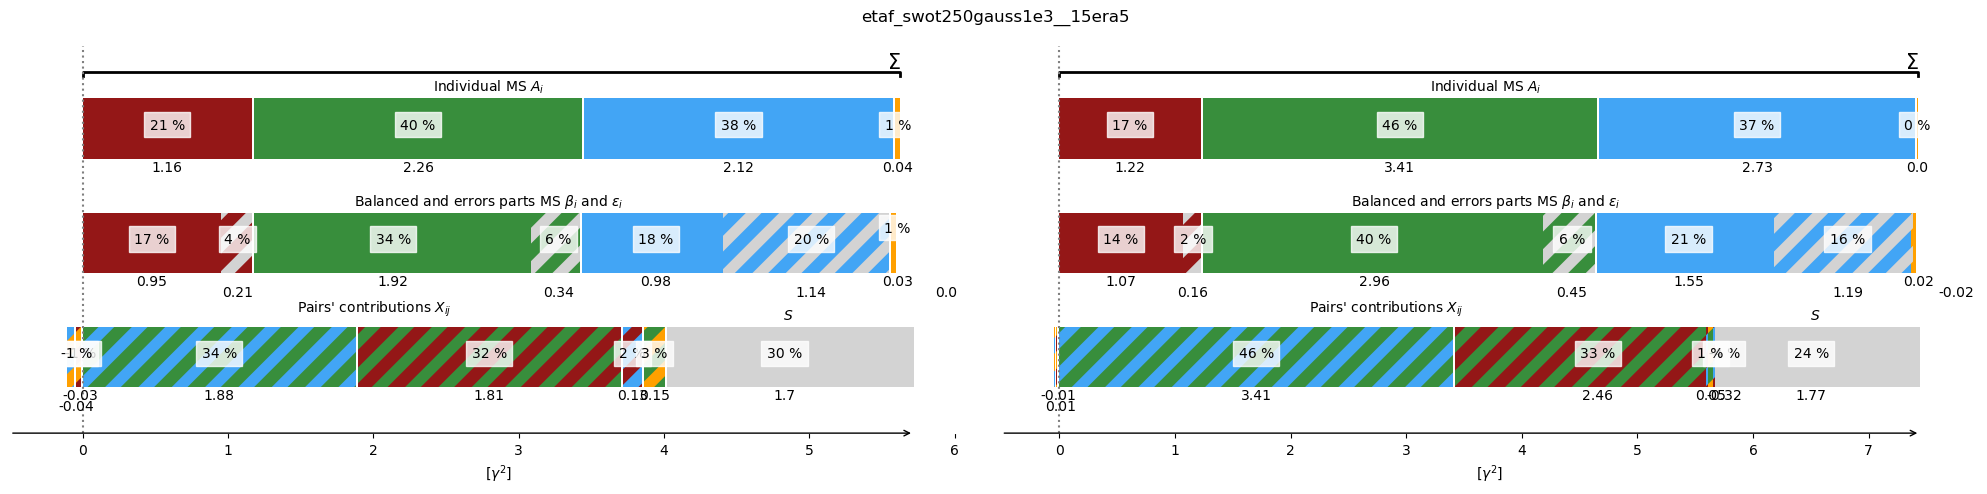

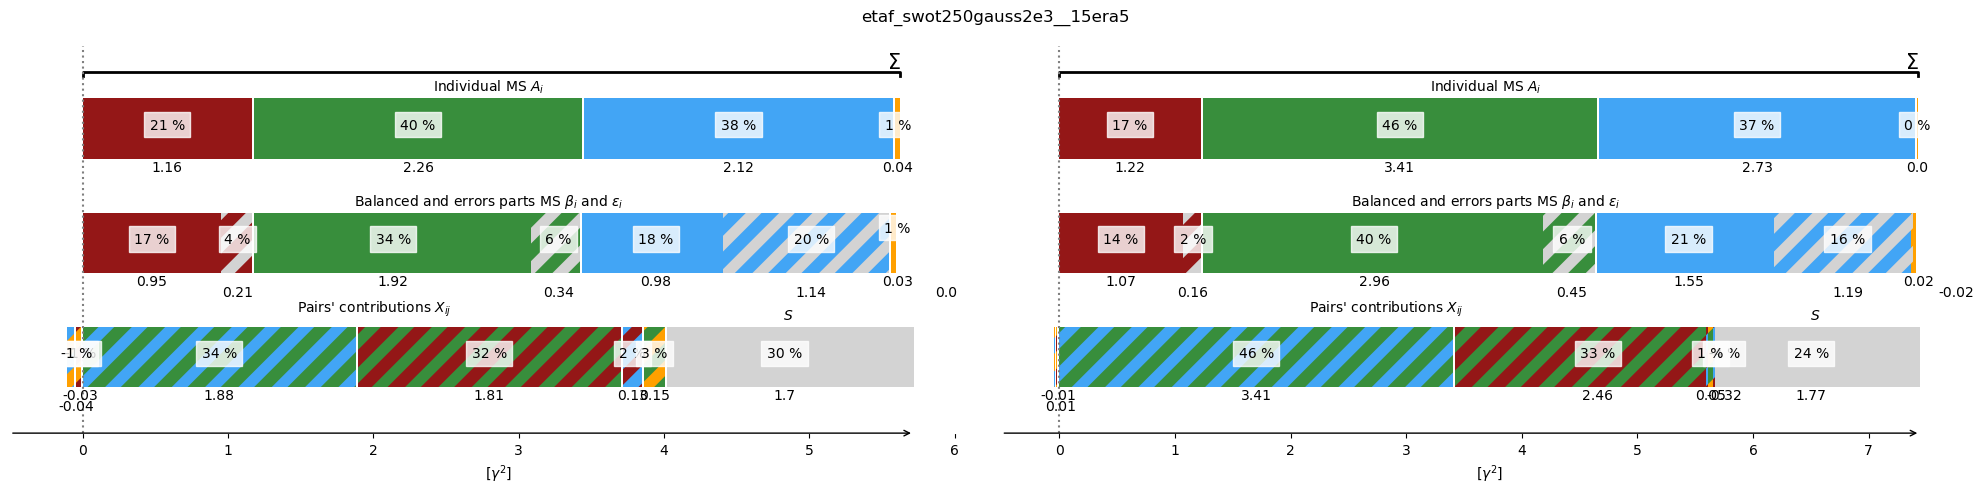

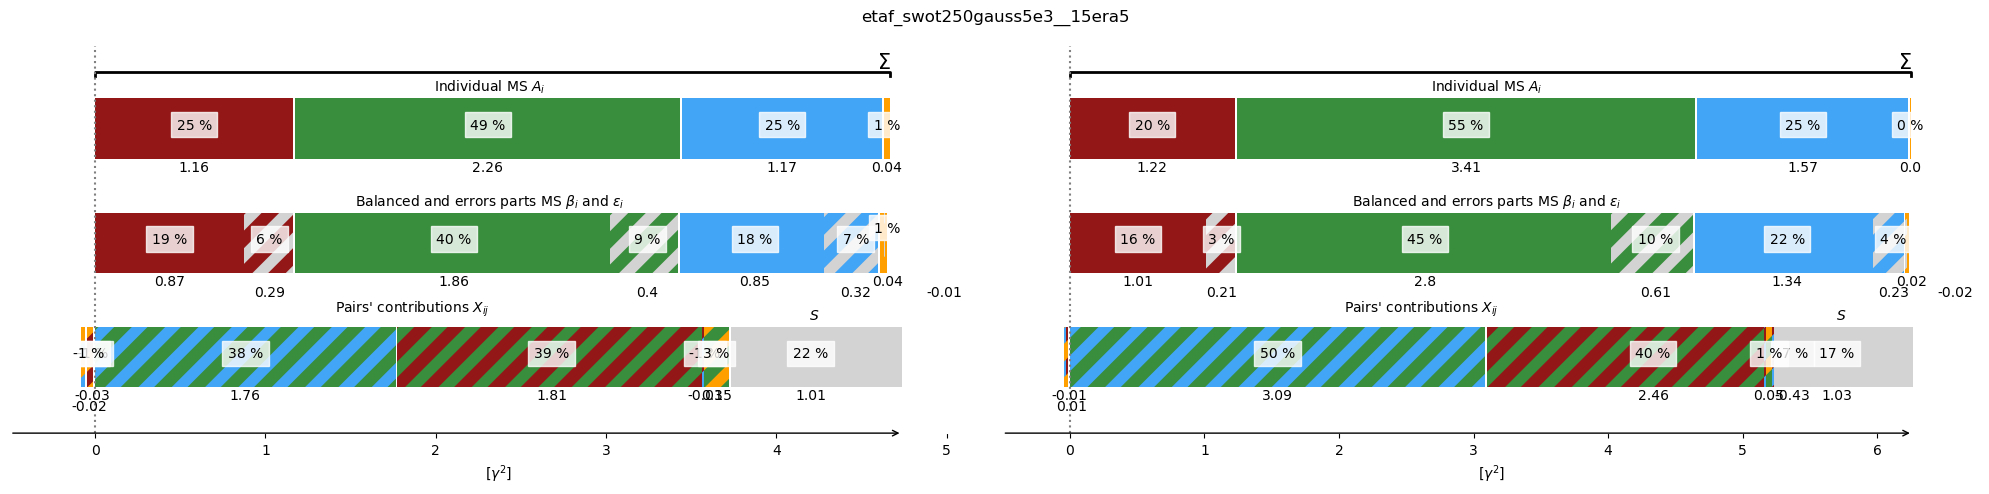

In [17]:
c = 'etaf_swot250naive__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

c = 'etaf_swot250gauss1e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

c = 'etaf_swot250gauss2e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

c = 'etaf_swot250gauss5e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

# Etaf, etac

4.633770664425903
4.73958974547408
6.202247339303583
6.2623602785133
4.661734564164215
4.761201244460434
6.2112122401862395
6.2708378004512415


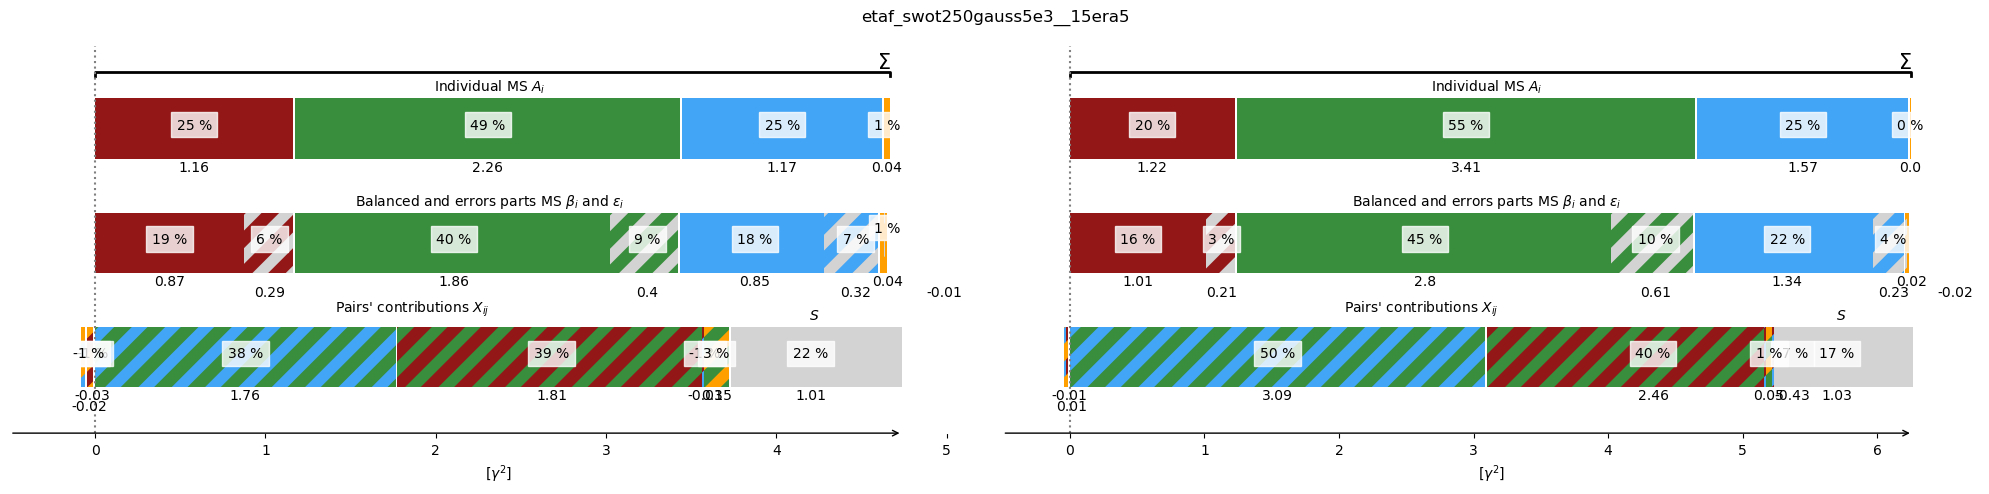

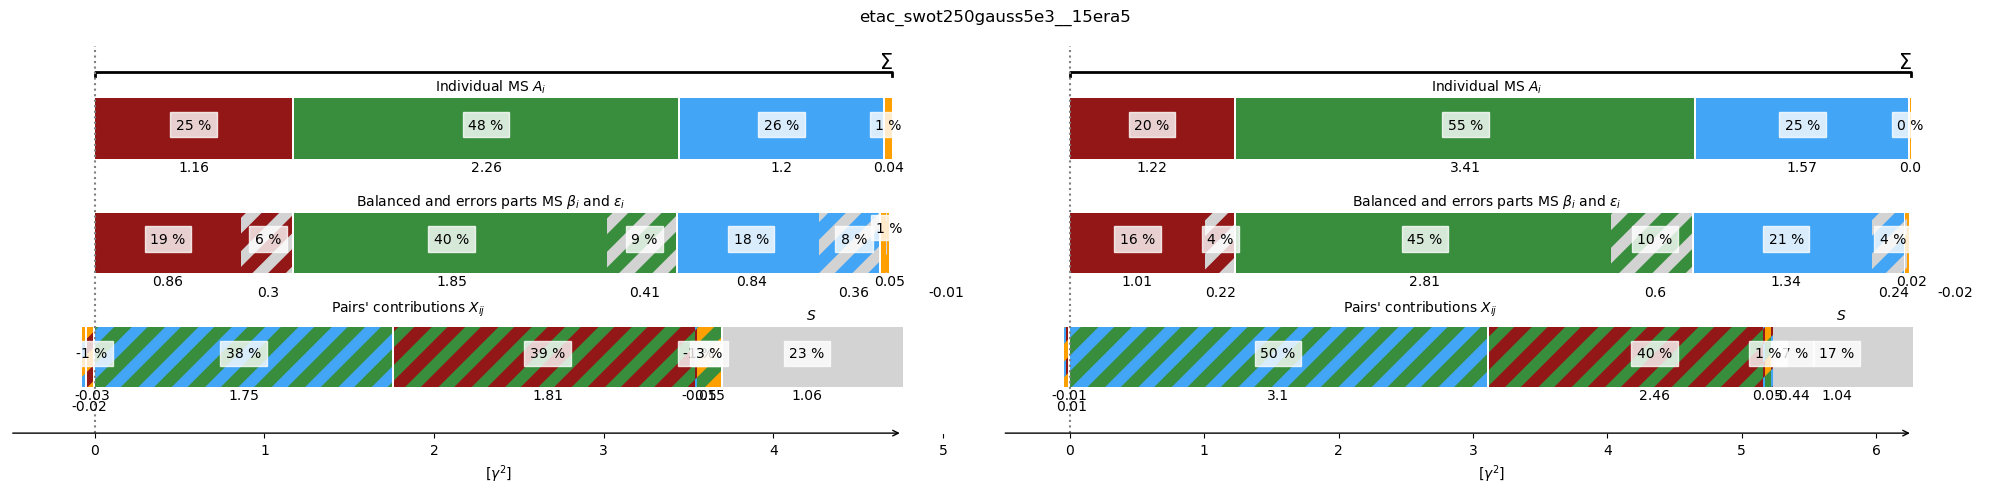

In [20]:
c = 'etaf_swot250gauss5e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

c = 'etac_swot250gauss5e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

4.633770664425903
4.73958974547408
6.202247339303583
6.2623602785133
4.621676791866464
4.7244103926240335
6.203722741149835
6.263867718202855


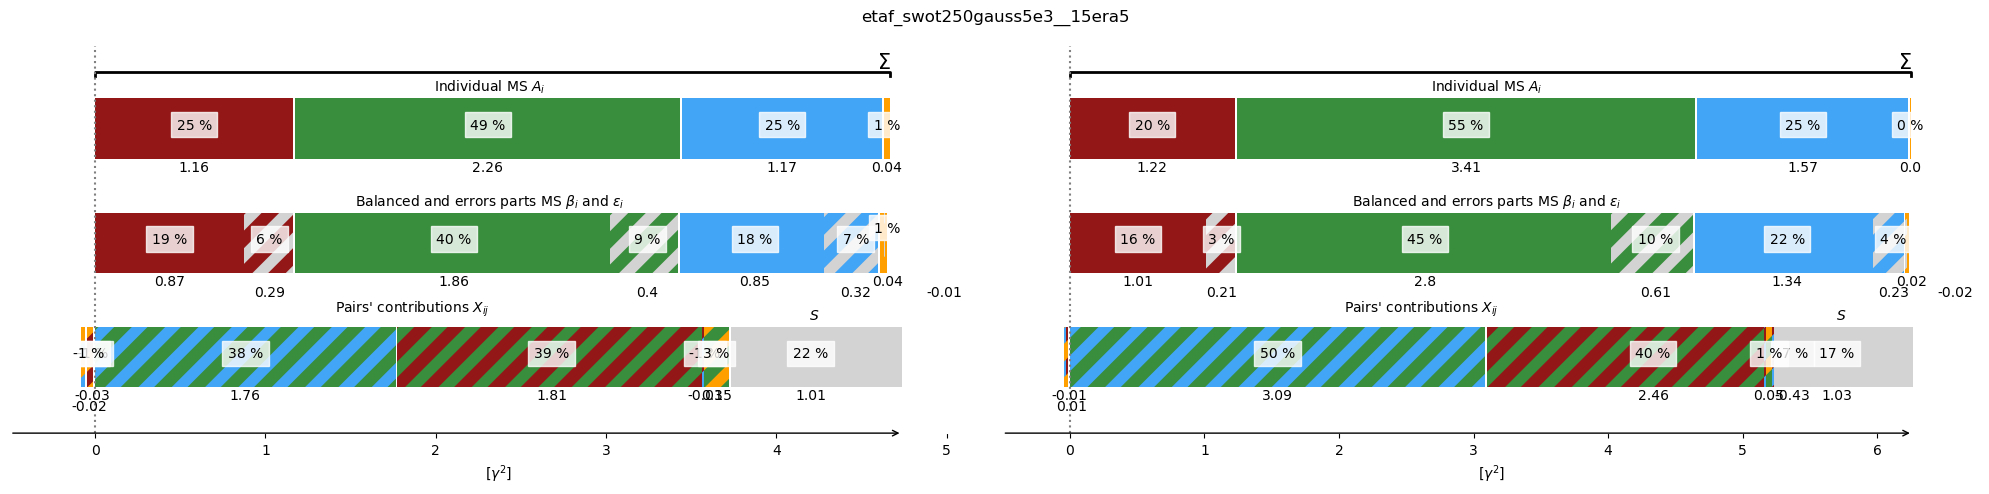

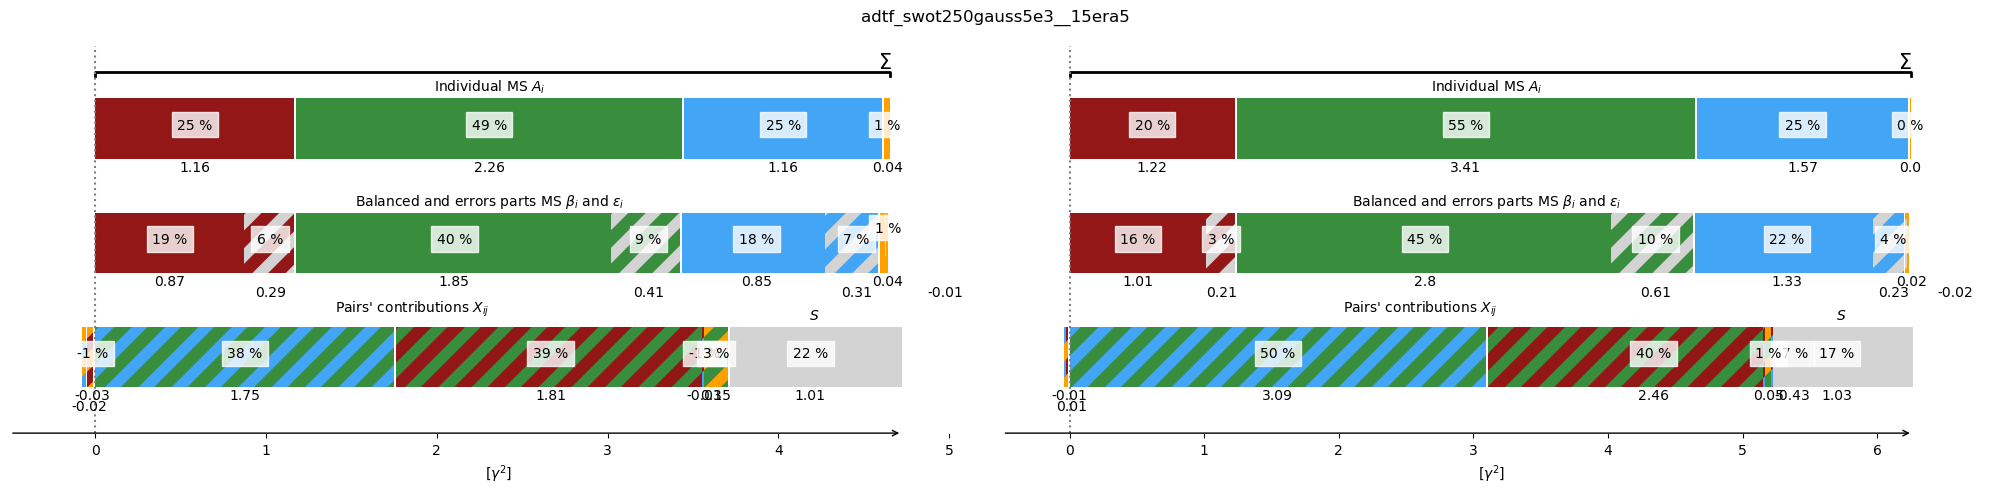

In [21]:
c = 'etaf_swot250gauss5e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

c = 'adtf_swot250gauss5e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()